# FinScore v2.0.7 — PUDIM

Modelo de **capacidade econômico-operacional e financeiro-patrimonial** baseado em três BPs e DREs.

> **Limite de uso:** o FinScore não estima probabilidade de inadimplência. Ele é um diagnóstico interno de capacidade econômica, condicionado à qualidade das demonstrações e às regras normativas versionadas.

### Alterações metodológicas da versão 2.0.7

1. cada indicador passou a separar **nível atual (60%)**, **trajetória (25%)** e **resiliência (15%)**;
2. o PCA passou a usar índices orientados e padronizados de forma robusta, com participação máxima de 15% e teste de estabilidade;
3. os núcleos passaram a ser agregados por média geométrica, com componente de gargalo e caps prudenciais;
4. foi criado um índice de confiabilidade separado do FinScore;
5. curvas excessivamente saturadas foram substituídas por tetos econômicos de 95 pontos;
6. o PL deixou de ser conta residual do Monte Carlo; ele é sorteado como driver explícito e o Ativo Total fecha a identidade;
7. foram incluídos cenários determinísticos, faixa de incerteza para classificação desconhecida da dívida e contribuição por indicador;
8. novos autotestes verificam monotonicidade, invariância monetária, não compensação, estabilidade do PCA e limites dos choques.

In [ ]:
# Principais mudanças implementadas:

# VERSAO_MODELO = "2.0.7";
# nível, trajetória e resiliência com pesos 60%–25%–15%;
# PCA sobre índices orientados e padronizados robustamente;
# participação do PCA limitada a 15%, condicionada à estabilidade;
# agregação geométrica dos núcleos com componente de gargalo;
# caps prudenciais para fragilidades patrimoniais críticas;
# índice de confiabilidade separado do FinScore;
# intervalo para dívida com classificação desconhecida;
# cenários determinísticos base, adverso e severo;
# Monte Carlo sem utilizar o PL como conta residual;
# caminho da planilha relativo e configurável por variável de ambiente;
# comentários, justificativas metodológicas e trilha de auditoria ampliados;
# exportação das contribuições, componentes temporais, caps e diagnósticos;
# 25 autotestes de propriedades do modelo.

## 0. Como usar

1. Informe `FINSCORE_PLANILHA` ou mantenha a planilha no caminho relativo indicado.
2. Confirme a aba de lançamentos e, quando aplicável, registre correções manuais documentadas.
3. Execute as células em ordem.
4. Analise conjuntamente: FinScore, núcleos, caps, confiabilidade, faixa de incerteza, alertas e cenários.
5. Somente utilize o resultado em decisão quando `classificacao_uso` permitir e as correções materiais estiverem confirmadas.

O notebook preserva a base reportada, calcula numa cópia analítica e registra toda intervenção relevante.

In [ ]:
# CONFIGURAÇÃO — edite apenas este bloco
import os
from datetime import datetime
from pathlib import Path

VERSAO_MODELO = "2.00.07"

# Hash das células de código com a própria linha do hash neutralizada.
# É preenchido na geração deste notebook e permite identificar a implementação.
HASH_CODIGO_MODELO = "f3bed4ffb78cc427923520c31a2d351acc3d3478a9a7b5c651f8924ba80b29d9"

# Caminho relativo por padrão: evita dependência do computador do analista.
CAMINHO_PLANILHA = Path(
    os.environ.get("FINSCORE_PLANILHA", "C:\\Users\\ferna\\Documents\\dev\\Finscore\\FinScore\\V. 2 (Pudim)\\dados_teste\\DADOS_V2_PUDIM_bp-dre4.xlsx")
)
ABA_DADOS = os.environ.get("FINSCORE_ABA", "lancamentos")

NUM_SIMULACOES = int(os.environ.get("FINSCORE_SIMULACOES", "3000"))
SEMENTE = int(os.environ.get("FINSCORE_SEMENTE", "20260723"))
EXECUTAR_AUTOTESTES = os.environ.get("FINSCORE_AUTOTESTES", "1") == "1"
EXPORTAR_EXCEL = os.environ.get("FINSCORE_EXPORTAR", "1") == "1"

# Política de correção:
# - a origem nunca é alterada;
# - correções automáticas só entram na cópia analítica quando a confiança
#   mínima é atingida;
# - toda correção automática material mantém o resultado como provisório.
POLITICA_CORRECAO = "HIERARQUIA_CONTABIL_CONTROLADA"
APLICAR_CORRECOES_AUTOMATICAS = True
LIMIAR_CONFIANCA_AUTOMATICA = 0.90
LIMIAR_MATERIALIDADE = 0.01       # 1% do Ativo Total
LIMIAR_VIES_ALTO = 0.05           # 5% do Ativo Total
PERMITIR_SCORE_PROVISORIO = True

# Ajustes manuais opcionais. Não use para "fazer fechar" sem documento-fonte.
# Exemplo:
# CORRECOES_MANUAIS = [{
#     "ano": 2025,
#     "conta": "p_Passivo_Nao_Circulante",
#     "valor": 123456.78,
#     "fonte": "BP assinado, p. 2",
#     "justificativa": "Erro de transcrição confirmado",
#     "responsavel": "Analista responsável",
#     "confirmado": True,
# }]
CORRECOES_MANUAIS = []

# Evidência comportamental externa: permanece separada do FinScore.
SERASA_SCORE = 700               # inteiro ou float entre 0 e 1.000
SERASA_DATA_CONSULTA = "2026-07-23"       # exemplo: "2026-07-23"
SERASA_RESTRICAO_GRAVE = False

DATA_HORA_PROCESSAMENTO = datetime.now()
ARQUIVO_SAIDA = Path(
    os.environ.get(
        "FINSCORE_SAIDA",
        f"resultados_finscore_{VERSAO_MODELO}_{DATA_HORA_PROCESSAMENTO:%Y%m%d_%H%M}.xlsx",
    )
)

print(f"Versão: {VERSAO_MODELO}")
print(f"Hash do código: {HASH_CODIGO_MODELO}")
print(f"Planilha: {CAMINHO_PLANILHA.resolve()}")
print(f"Aba: {ABA_DADOS}")

Versão: 2.0.7
Hash do código: f3bed4ffb78cc427923520c31a2d351acc3d3478a9a7b5c651f8924ba80b29d9
Planilha: C:\Users\ferna\Documents\dev\Finscore\FinScore\V. 2 (Pudim)\dados_teste\DADOS_V2_PUDIM_bp-dre4.xlsx
Aba: lancamentos


In [17]:
if not CAMINHO_PLANILHA.exists():
    disponiveis = sorted(Path.cwd().glob("*.xlsx"))
    print("Arquivo não encontrado. Planilhas disponíveis nesta pasta:")
    for arquivo in disponiveis:
        print(" -", arquivo.name)
    raise FileNotFoundError(
        f"Ajuste CAMINHO_PLANILHA. Não foi encontrado: {CAMINHO_PLANILHA}"
    )


## 1. Ambiente, contas e premissas


In [18]:
import math
import re
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

PRIMARY = [
    "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
    "p_Ativo_Circulante", "p_Imobilizado_Liquido", "p_Ativo_Total",
    "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
    "p_Obrigacoes_Trabalhistas_CP", "p_Passivo_Circulante",
    "p_Passivo_Nao_Circulante", "p_Emprestimos_Financiamentos_CP",
    "p_Emprestimos_Financiamentos_LP", "p_Patrimonio_Liquido",
    "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Resultado_Antes_IR_CSLL",
    "r_Lucro_Liquido", "r_Receitas_Financeiras", "r_Despesa_de_Impostos",
    "r_Despesas_Financeiras",
]

SIGNED_ACCOUNTS = {
    "p_Patrimonio_Liquido", "r_Resultado_Antes_IR_CSLL", "r_Lucro_Liquido",
}
STRICTLY_POSITIVE = {"p_Ativo_Total"}
NONNEGATIVE = set(PRIMARY) - SIGNED_ACCOUNTS

# Parâmetros gerais e de sensibilidade.
DELTA_MIN = 0.05
DELTA_MAX = 0.35
BALANCE_TOLERANCE = 0.01
MAX_ATTEMPT_FACTOR = 40
MIN_NUCLEUS_COVERAGE = 0.70
SENSITIVITY_THRESHOLDS = [125, 250, 500]

# A nota temporal deixa de ser uma média opaca dos três anos.
# Nível atual domina; trajetória e pior desempenho evitam leitura pontual.
TEMPORAL_COMPONENT_WEIGHTS = {
    "nivel_atual": 0.60,
    "trajetoria": 0.25,
    "resiliencia": 0.15,
}

# O PCA é diagnóstico auxiliar. Com três observações, não pode definir sozinho
# a relevância econômica dos indicadores.
PCA_ADAPTIVE_SHARE = 0.15
PCA_MIN_ACTIVE_VARIABLES = 3
PCA_STABILITY_REPETITIONS = 160
PCA_PERTURBATION_SD = 0.05
PCA_MAX_MEAN_L1_DISTANCE = 0.25
PCA_MIN_MEAN_COSINE = 0.90
PCA_MAX_PURE_WEIGHT = 0.60
PCA_ROBUST_CLIP = 3.5
PCA_STABILITY_SEED = 207

# Agregação não compensatória dos núcleos.
NUCLEUS_WEIGHTS = {"EO": 0.45, "FP": 0.55}
BOTTLENECK_SHARE = 0.25

# Caps preliminares e versionados. Eles não substituem calibração setorial;
# impedem apenas que uma condição patrimonial crítica receba nota incompatível.
PRUDENTIAL_CAPS = {
    "pl_negativo": 350.0,
    "pl_ativo_abaixo_2pct": 500.0,
    "pl_ativo_abaixo_5pct": 650.0,
    "endividamento_maior_igual_100pct": 500.0,
    "endividamento_maior_igual_95pct": 650.0,
    "cobertura_juros_abaixo_1x": 500.0,
}

# r_Despesas_Financeiras só pode representar juros quando a origem da conta
# tiver sido conferida. Se False, Cobertura de Juros ficará indisponível.
USAR_DESPESAS_FINANCEIRAS_COMO_PROXY_JUROS = True
COBERTURA_JUROS_TETO_ECONOMICO = 10.0

# Pesos estruturais: trajetória do EBIT já é capturada no bloco temporal.
# Capitalização entra explicitamente; capitalização e endividamento têm peso
# combinado limitado para reduzir redundância contábil.
FIXED_WEIGHTS = {
    "crescimento_receita": 0.15,
    "margem_bruta": 0.10,
    "margem_ebit": 0.30,
    "margem_liquida": 0.20,
    "giro_ativo": 0.25,
    "capitalizacao": 0.20,
    "endividamento_exigivel": 0.10,
    "liquidez_corrente": 0.15,
    "liquidez_seca": 0.10,
    "ccl_ativo": 0.10,
    "divida_liquida_ativo": 0.10,
    "cobertura_juros": 0.15,
    "composicao_endividamento": 0.10,
}

NUCLEI = {
    "EO": [
        "crescimento_receita", "margem_bruta", "margem_ebit",
        "margem_liquida", "giro_ativo",
    ],
    "FP": [
        "capitalizacao", "endividamento_exigivel", "liquidez_corrente",
        "liquidez_seca", "ccl_ativo", "divida_liquida_ativo",
        "cobertura_juros", "composicao_endividamento",
    ],
}

# Curvas normativas preliminares. O teto econômico é 95, não 100:
# valor extremo gera alerta de plausibilidade, não prêmio adicional.
CURVE_MAX_SCORE = 95.0
ANCHORS = {
    "crescimento_receita": [
        (-0.30, 0), (0, 45), (0.10, 70), (0.25, 90), (0.50, 95),
    ],
    "margem_bruta": [
        (-0.10, 0), (0, 10), (0.15, 45), (0.30, 75), (0.50, 95),
    ],
    "margem_ebit": [
        (-0.20, 0), (0, 35), (0.10, 70), (0.20, 90), (0.35, 95),
    ],
    "margem_liquida": [
        (-0.20, 0), (0, 35), (0.07, 70), (0.15, 90), (0.25, 95),
    ],
    "giro_ativo": [
        (0, 0), (0.30, 25), (0.70, 60), (1.20, 85), (2, 95), (5, 95),
    ],
    "capitalizacao": [
        (-0.20, 0), (0, 5), (0.05, 20), (0.15, 50), (0.30, 80), (0.50, 95),
    ],
    "endividamento_exigivel": [
        (0, 95), (0.30, 85), (0.50, 60), (0.70, 30), (1, 0), (1.50, 0),
    ],
    "liquidez_corrente": [
        (0, 0), (0.70, 10), (1, 45), (1.30, 70), (1.80, 95), (4, 95),
    ],
    "liquidez_seca": [
        (0, 0), (0.50, 10), (0.80, 40), (1.10, 70), (1.50, 95), (3, 95),
    ],
    "ccl_ativo": [
        (-0.50, 0), (-0.10, 15), (0, 45), (0.10, 65), (0.25, 85), (0.50, 95),
    ],
    "divida_liquida_ativo": [
        (-0.30, 95), (0, 90), (0.20, 70), (0.40, 35), (0.70, 0),
    ],
    "composicao_endividamento": [
        (0, 95), (0.30, 80), (0.50, 55), (0.75, 25), (1, 0),
    ],
    "cobertura_juros": [
        (-2, 0), (0, 5), (1, 25), (2, 55), (4, 80), (10, 95), (50, 95),
    ],
}

# Orientação usada apenas para leitura das cargas do PCA.
# A importância usa cargas absolutas e, portanto, não depende do sinal.
INDICATOR_DIRECTION = {
    "endividamento_exigivel": -1,
    "divida_liquida_ativo": -1,
    "composicao_endividamento": -1,
}

# Somente drivers são sorteados. Totais contábeis e resultados conciliados são
# derivados; por isso não se atribui a eles uma "amplitude declarada" falsa.
SIMULATION_DRIVER_ACCOUNTS = {
    "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
    "p_Imobilizado_Liquido", "p_Fornecedores",
    "p_Obrigacoes_Tributarias_CP", "p_Obrigacoes_Trabalhistas_CP",
    "p_Emprestimos_Financiamentos_CP",
    "p_Emprestimos_Financiamentos_LP", "p_Patrimonio_Liquido",
    "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Receitas_Financeiras",
    "r_Despesa_de_Impostos", "r_Despesas_Financeiras",
}
DERIVED_SIMULATION_ACCOUNTS = set(PRIMARY) - SIMULATION_DRIVER_ACCOUNTS

SCENARIO_DEFINITIONS = {
    "BASE": {
        "descricao": "Manutenção aproximada da estrutura observada.",
        "receita": 0.00, "margem_ebit": 0.00, "contas_receber": 0.00,
        "estoques": 0.00, "caixa": 0.00, "juros": 0.00,
        "divida": 0.00, "pl": 0.00, "pc_total": 0.00, "pnc_total": 0.00,
    },
    "ADVERSO": {
        "descricao": "Queda de receita, compressão de margem e pressão de capital de giro.",
        "receita": -0.10, "margem_ebit": -0.20, "contas_receber": 0.15,
        "estoques": 0.10, "caixa": -0.15, "juros": 0.25,
        "divida": 0.10, "pl": -0.10, "pc_total": 0.08, "pnc_total": 0.05,
    },
    "SEVERO": {
        "descricao": "Estresse forte de atividade, margem, liquidez e custo financeiro.",
        "receita": -0.25, "margem_ebit": -0.40, "contas_receber": 0.30,
        "estoques": 0.20, "caixa": -0.30, "juros": 0.60,
        "divida": 0.25, "pl": -0.25, "pc_total": 0.18, "pnc_total": 0.12,
    },
}

assert len(PRIMARY) == 21
assert np.isclose(sum(TEMPORAL_COMPONENT_WEIGHTS.values()), 1.0)
assert np.isclose(sum(NUCLEUS_WEIGHTS.values()), 1.0)
for nucleo, colunas in NUCLEI.items():
    assert np.isclose(sum(FIXED_WEIGHTS[c] for c in colunas), 1.0)

print("Ambiente carregado e premissas estruturais da v2.0.7 verificadas.")

Ambiente carregado e premissas estruturais da v2.0.7 verificadas.


### Regras metodológicas da correção

- `NaN` significa ausência ou impossibilidade de cálculo; nunca é convertido silenciosamente em zero.
- A base original permanece imutável e recebe hash próprio.
- Toda correção ou quarentena é registrada com regra, materialidade, confiança, impacto e confirmação.
- Reconciliação algorítmica não equivale a validação documental.
- O FinScore e a confiabilidade são apresentados separadamente.
- As curvas, pesos, caps e regras de estabilidade são normativos e precisam de calibração futura por setor e porte.

## 2. Importação, correção controlada e preparação da base

O bloco seguinte é deliberadamente comentado em detalhe. Ele constitui a
principal trilha de auditoria da v2.0.2.


In [19]:
import hashlib
import json


QUALITY_COLUMNS = [
    "severidade", "tipo", "conta", "exercicios", "detalhe",
    "bloqueia_calculo", "bloqueia_decisao", "bloqueia_score",
]

AUDIT_COLUMNS = [
    "evento_id", "data_hora", "etapa", "acao", "status_acao", "ano", "conta",
    "valor_original", "valor_proposto", "valor_utilizado", "delta_absoluto",
    "delta_percentual", "materialidade_pct_ativo", "regra_id",
    "regra_descricao", "evidencia", "confianca", "potencial_vies",
    "indicadores_afetados", "requer_confirmacao", "confirmado",
    "bloqueia_calculo", "bloqueia_decisao", "fonte", "responsavel",
]


def safe_div(a: pd.Series, b: pd.Series) -> pd.Series:
    # Tolerância relativa evita divisões por denominadores materialmente nulos.
    b_float = b.astype(float)
    scale = max(float(b_float.abs().median(skipna=True) or 0.0), 1.0)
    denominator = b_float.where(b_float.abs() > 1e-9 * scale)
    return a.astype(float).div(denominator).replace([np.inf, -np.inf], np.nan)


def _is_blank_accounting_value(value) -> bool:
    if pd.isna(value):
        return True
    return str(value).strip().lower() in {
        "", "-", "--", "n/a", "na", "nan", "none", "null"
    }


def parse_accounting_value(value) -> float:
    # Converte números e textos contábeis sem confundir ausência com zero.
    if _is_blank_accounting_value(value):
        return np.nan
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value) if np.isfinite(value) else np.nan

    text = str(value).strip()
    negative_parentheses = text.startswith("(") and text.endswith(")")
    text = re.sub(r"[^0-9,\.\-+]", "", text)
    if not text or text in {"-", "+", ".", ","}:
        return np.nan

    if "," in text and "." in text:
        if text.rfind(",") > text.rfind("."):
            text = text.replace(".", "").replace(",", ".")
        else:
            text = text.replace(",", "")
    elif "," in text:
        parts = text.split(",")
        text = (
            "".join(parts)
            if len(parts[-1]) == 3 and len(parts) > 1
            else text.replace(",", ".")
        )
    elif text.count(".") > 1:
        parts = text.split(".")
        text = (
            "".join(parts)
            if len(parts[-1]) == 3
            else "".join(parts[:-1]) + "." + parts[-1]
        )

    try:
        number = float(text)
    except ValueError:
        return np.nan
    return -abs(number) if negative_parentheses else number


def dataframe_sha256(df: pd.DataFrame) -> str:
    # O hash permite provar se a base usada numa execução foi alterada.
    normalized = df.copy()
    normalized = normalized.reindex(sorted(normalized.columns), axis=1)
    payload = pd.util.hash_pandas_object(
        normalized, index=True, categorize=True
    ).values.tobytes()
    return hashlib.sha256(payload).hexdigest()


def load_raw_data(path: Path, sheet_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    source = pd.read_excel(path, sheet_name=sheet_name)
    missing_columns = [c for c in ["ano", *PRIMARY] if c not in source.columns]
    if missing_columns:
        raise ValueError(f"Colunas ausentes na aba {sheet_name}: {missing_columns}")

    source = source[["ano", *PRIMARY]].dropna(how="all", subset=PRIMARY).copy()
    if len(source) != 3:
        raise ValueError(f"A aba deve ter 3 exercícios preenchidos; encontrei {len(source)}.")

    year_numeric = pd.to_numeric(source["ano"], errors="coerce")
    invalid_year = year_numeric.isna() | (year_numeric <= 0) | (year_numeric % 1 != 0)
    if invalid_year.any():
        rows = (source.index[invalid_year] + 2).tolist()
        raise ValueError(f"Exercício/ano deve ser inteiro positivo. Linhas inválidas: {rows}")
    source["ano"] = year_numeric.astype(int)
    if source["ano"].duplicated().any():
        years = source.loc[source["ano"].duplicated(keep=False), "ano"].tolist()
        raise ValueError(f"Há exercícios duplicados: {years}")
    source = source.sort_values("ano").reset_index(drop=True)

    report = []
    for column in PRIMARY:
        original = source[column].copy()
        converted = original.map(parse_accounting_value)
        blank = original.map(_is_blank_accounting_value)
        invalid = converted.isna() & ~blank
        absent = converted.isna() & blank
        if invalid.any():
            report.append({
                "severidade": "CRITICA",
                "tipo": "erro_conversao",
                "conta": column,
                "exercicios": ", ".join(source.loc[invalid, "ano"].astype(str)),
                "detalhe": "Valor textual não pôde ser convertido; revisar a origem.",
                "bloqueia_calculo": True,
                "bloqueia_decisao": True,
                "bloqueia_score": True,
            })
        if absent.any():
            report.append({
                "severidade": "AVISO",
                "tipo": "ausencia",
                "conta": column,
                "exercicios": ", ".join(source.loc[absent, "ano"].astype(str)),
                "detalhe": "Informação ausente preservada como NaN; não equivale a zero.",
                "bloqueia_calculo": False,
                "bloqueia_decisao": False,
                "bloqueia_score": False,
            })
        source[column] = converted

    return source, pd.DataFrame(report, columns=QUALITY_COLUMNS)


def _known_sum(row: pd.Series, columns: list[str]) -> float:
    values = row[columns]
    return float(values.sum(skipna=True)) if values.notna().any() else np.nan


def _balance_implied(row: pd.Series, account: str) -> float:
    at = row["p_Ativo_Total"]
    pc = row["p_Passivo_Circulante"]
    pnc = row["p_Passivo_Nao_Circulante"]
    pl = row["p_Patrimonio_Liquido"]
    return {
        "p_Ativo_Total": pc + pnc + pl,
        "p_Passivo_Circulante": at - pnc - pl,
        "p_Passivo_Nao_Circulante": at - pc - pl,
        "p_Patrimonio_Liquido": at - pc - pnc,
    }[account]


def validate_correct_and_prepare(
    raw: pd.DataFrame,
    import_report: pd.DataFrame,
    manual_corrections: list[dict] | None = None,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, dict]:
    '''
    Cria uma cópia analítica corrigida sem modificar `raw`.

    A função separa:
    1. erro comprovável/correção;
    2. inferência por identidade;
    3. conflito não identificável/quarentena;
    4. problema ainda impeditivo.
    '''
    analysis = raw.copy(deep=True)
    issues = import_report.to_dict("records")
    audit: list[dict] = []
    manual_corrections = manual_corrections or []

    def add_issue(severity, kind, account, year, detail, calc=False, decision=False):
        issues.append({
            "severidade": severity,
            "tipo": kind,
            "conta": account,
            "exercicios": str(year),
            "detalhe": detail,
            "bloqueia_calculo": bool(calc),
            "bloqueia_decisao": bool(decision),
            "bloqueia_score": bool(calc),
        })

    def add_audit(
        *,
        stage,
        action,
        status_action,
        year,
        account,
        original,
        proposed,
        used,
        rule_id,
        rule_description,
        evidence,
        confidence,
        bias,
        indicators,
        requires_confirmation,
        confirmed,
        blocks_calculation,
        blocks_decision,
        source="",
        responsible="",
    ):
        at = raw.loc[raw["ano"].eq(year), "p_Ativo_Total"]
        at_value = float(at.iloc[0]) if len(at) and pd.notna(at.iloc[0]) else np.nan
        delta = (
            float(used - original)
            if pd.notna(used) and pd.notna(original)
            else np.nan
        )
        delta_pct = (
            delta / abs(float(original))
            if pd.notna(delta) and pd.notna(original) and abs(float(original)) > 1e-12
            else np.nan
        )
        if pd.notna(at_value) and abs(at_value) > 1e-12:
            if pd.notna(delta):
                materiality = abs(delta) / abs(at_value)
            elif pd.isna(original) and pd.notna(used):
                materiality = abs(float(used)) / abs(at_value)
            elif pd.notna(original) and pd.isna(used):
                materiality = abs(float(original)) / abs(at_value)
            elif pd.notna(proposed) and pd.notna(original):
                materiality = abs(float(proposed) - float(original)) / abs(at_value)
            else:
                materiality = np.nan
        else:
            materiality = np.nan
        audit.append({
            "evento_id": f"EVT-{len(audit) + 1:04d}",
            "data_hora": DATA_HORA_PROCESSAMENTO.strftime("%Y-%m-%d %H:%M:%S"),
            "etapa": stage,
            "acao": action,
            "status_acao": status_action,
            "ano": int(year),
            "conta": account,
            "valor_original": original,
            "valor_proposto": proposed,
            "valor_utilizado": used,
            "delta_absoluto": delta,
            "delta_percentual": delta_pct,
            "materialidade_pct_ativo": materiality,
            "regra_id": rule_id,
            "regra_descricao": rule_description,
            "evidencia": evidence,
            "confianca": confidence,
            "potencial_vies": bias,
            "indicadores_afetados": indicators,
            "requer_confirmacao": bool(requires_confirmation),
            "confirmado": bool(confirmed),
            "bloqueia_calculo": bool(blocks_calculation),
            "bloqueia_decisao": bool(blocks_decision),
            "fonte": source,
            "responsavel": responsible,
        })

    years = raw["ano"].astype(int).tolist()
    if any(b - a != 1 for a, b in zip(years[:-1], years[1:])):
        add_issue(
            "AVISO", "serie_temporal", "ano", ", ".join(map(str, years)),
            "Os três exercícios não são consecutivos.", False, False
        )

    # ETAPA A — correções manuais documentadas têm precedência.
    for correction in manual_corrections:
        year = int(correction["ano"])
        account = correction["conta"]
        if account not in PRIMARY:
            raise ValueError(f"Conta inválida em CORRECOES_MANUAIS: {account}")
        matches = analysis.index[analysis["ano"].eq(year)]
        if len(matches) != 1:
            raise ValueError(f"Exercício não encontrado em correção manual: {year}")
        if not correction.get("fonte") or not correction.get("justificativa"):
            raise ValueError(
                "Correção manual exige `fonte` e `justificativa`."
            )
        idx = matches[0]
        original = analysis.at[idx, account]
        proposed = parse_accounting_value(correction["valor"])
        confirmed = bool(correction.get("confirmado", False))
        if pd.isna(proposed):
            raise ValueError(f"Valor inválido na correção manual de {account}/{year}.")
        analysis.at[idx, account] = proposed
        add_audit(
            stage="CORRECAO_MANUAL",
            action="SUBSTITUICAO_DOCUMENTADA",
            status_action="APLICADA",
            year=year,
            account=account,
            original=original,
            proposed=proposed,
            used=proposed,
            rule_id="R-MAN-001",
            rule_description="Correção manual baseada em documento-fonte.",
            evidence=correction["justificativa"],
            confidence=1.0 if confirmed else 0.75,
            bias="ALTO" if not confirmed else "CONTROLADO",
            indicators="Todos os índices dependentes da conta.",
            requires_confirmation=True,
            confirmed=confirmed,
            blocks_calculation=False,
            blocks_decision=not confirmed,
            source=correction["fonte"],
            responsible=correction.get("responsavel", ""),
        )

    # ETAPA B — corrige para zero uma única rubrica cuja retirada reconcilia
    # exatamente o balanço. Isso evita escolher PL/AT/PC como "conta plug".
    balance_cols = [
        "p_Ativo_Total", "p_Passivo_Circulante",
        "p_Passivo_Nao_Circulante", "p_Patrimonio_Liquido",
    ]
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        if not row[balance_cols].notna().all():
            continue
        at = float(row["p_Ativo_Total"])
        tolerance = BALANCE_TOLERANCE * max(abs(at), 1.0)
        difference = (
            row["p_Ativo_Total"] - row["p_Passivo_Circulante"]
            - row["p_Passivo_Nao_Circulante"] - row["p_Patrimonio_Liquido"]
        )
        if abs(difference) <= tolerance:
            continue

        removable = []
        for account in [
            "p_Passivo_Circulante",
            "p_Passivo_Nao_Circulante",
            "p_Patrimonio_Liquido",
        ]:
            implied = _balance_implied(row, account)
            if abs(implied) <= tolerance and abs(float(row[account])) > tolerance:
                removable.append((account, float(implied)))

        if len(removable) == 1:
            account, _implied = removable[0]
            # A diferença residual pode ser um artefato de ponto flutuante.
            # A regra é semanticamente "saldo zero", portanto grava 0.0 exato.
            proposed = 0.0
            original = float(row[account])
            confidence = 0.97
            apply = (
                APLICAR_CORRECOES_AUTOMATICAS
                and confidence >= LIMIAR_CONFIANCA_AUTOMATICA
            )
            used = proposed if apply else original
            if apply:
                analysis.at[idx, account] = proposed
            material = abs(original - proposed) / max(abs(at), 1.0)
            bias = "CRITICO" if material >= 0.10 else "ALTO"
            add_audit(
                stage="RECONCILIACAO_BP",
                action="CORRECAO_AUTOMATICA_PARA_ZERO",
                status_action="APLICADA" if apply else "PROPOSTA",
                year=year,
                account=account,
                original=original,
                proposed=proposed,
                used=used,
                rule_id="R-BAL-001",
                rule_description=(
                    "Única rubrica cuja retirada faz Ativo = PC + PNC + PL."
                ),
                evidence=(
                    f"Valor implícito pela identidade: {proposed:,.2f}; "
                    f"diferença anterior: {difference:,.2f}."
                ),
                confidence=confidence,
                bias=bias,
                indicators="Endividamento, composição do passivo e score FP.",
                requires_confirmation=True,
                confirmed=False,
                blocks_calculation=not apply,
                blocks_decision=True,
            )
        else:
            add_issue(
                "CRITICA", "balanco_nao_fecha", "p_Patrimonio_Liquido", year,
                f"Diferença de fechamento: {difference:,.2f} "
                f"({difference / at:.2%} do ativo); correção não unívoca.",
                True, True,
            )

    # ETAPA C — infere uma única parcela ausente da identidade principal.
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        absent = [c for c in balance_cols if pd.isna(row[c])]
        if len(absent) != 1:
            continue
        account = absent[0]
        proposed = _balance_implied(row, account)
        valid = np.isfinite(proposed)
        valid &= proposed > 0 if account == "p_Ativo_Total" else True
        valid &= proposed >= 0 if account in {
            "p_Passivo_Circulante", "p_Passivo_Nao_Circulante"
        } else True
        confidence = 0.99 if valid else 0.0
        apply = (
            valid
            and APLICAR_CORRECOES_AUTOMATICAS
            and confidence >= LIMIAR_CONFIANCA_AUTOMATICA
        )
        if apply:
            analysis.at[idx, account] = float(proposed)
        at = row["p_Ativo_Total"]
        material = (
            abs(float(proposed)) / max(abs(float(at)), 1.0)
            if valid and pd.notna(at) else np.nan
        )
        bias = (
            "CRITICO" if pd.notna(material) and material >= 0.10
            else "ALTO" if pd.notna(material) and material >= 0.05
            else "MODERADO"
        )
        add_audit(
            stage="RECONCILIACAO_BP",
            action="INFERENCIA_IDENTIDADE",
            status_action="APLICADA" if apply else "REJEITADA",
            year=year,
            account=account,
            original=np.nan,
            proposed=proposed,
            used=proposed if apply else np.nan,
            rule_id="R-BAL-002",
            rule_description=(
                "Única parcela ausente inferida por Ativo = PC + PNC + PL."
            ),
            evidence="Os outros três elementos da identidade estão presentes.",
            confidence=confidence,
            bias=bias,
            indicators="Todos os índices dependentes da parcela inferida.",
            requires_confirmation=True,
            confirmed=False,
            blocks_calculation=not apply,
            blocks_decision=True,
        )

    # ETAPA D — se o detalhamento excede o subtotal, não se escolhe uma conta
    # como errada. O grupo é retirado apenas da cópia analítica.
    subtotal_rules = [
        (
            "p_Ativo_Circulante",
            ["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"],
            "R-SUB-AC-001",
        ),
        (
            "p_Passivo_Circulante",
            [
                "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
                "p_Obrigacoes_Trabalhistas_CP",
                "p_Emprestimos_Financiamentos_CP",
            ],
            "R-SUB-PC-001",
        ),
        (
            "p_Passivo_Nao_Circulante",
            ["p_Emprestimos_Financiamentos_LP"],
            "R-SUB-PNC-001",
        ),
    ]
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        at = row["p_Ativo_Total"]
        for subtotal, parts, rule_id in subtotal_rules:
            if pd.isna(row[subtotal]):
                continue
            known = _known_sum(row, parts)
            tolerance = BALANCE_TOLERANCE * max(abs(float(row[subtotal])), 1.0)
            excess = known - float(row[subtotal]) if pd.notna(known) else np.nan
            if pd.isna(excess) or excess <= tolerance:
                continue
            material = (
                excess / max(abs(float(at)), 1.0) if pd.notna(at) else np.nan
            )
            bias = (
                "CRITICO" if pd.notna(material) and material >= LIMIAR_VIES_ALTO
                else "ALTO"
            )
            add_issue(
                "CRITICA", "subtotal_inferior_componentes", subtotal, year,
                f"Componentes excedem o subtotal em {excess:,.2f}. "
                "Detalhamento colocado em quarentena na base analítica.",
                False, True,
            )
            for part in parts:
                original = analysis.at[idx, part]
                if pd.isna(original):
                    continue
                analysis.at[idx, part] = np.nan
                add_audit(
                    stage="CONTROLE_SUBTOTAIS",
                    action="QUARENTENA_DETALHAMENTO",
                    status_action="APLICADA",
                    year=year,
                    account=part,
                    original=original,
                    proposed=np.nan,
                    used=np.nan,
                    rule_id=rule_id,
                    rule_description=(
                        f"Detalhamento incompatível com o subtotal {subtotal}; "
                        "nenhuma rubrica foi escolhida arbitrariamente."
                    ),
                    evidence=(
                        f"Soma conhecida: {known:,.2f}; subtotal: "
                        f"{row[subtotal]:,.2f}; excesso: {excess:,.2f}."
                    ),
                    confidence=1.0,
                    bias=bias,
                    indicators=(
                        "Dívida financeira, NCG, saldo de tesouraria e métricas "
                        "dependentes do detalhamento."
                    ),
                    requires_confirmation=True,
                    confirmed=False,
                    blocks_calculation=False,
                    blocks_decision=True,
                )

    # ETAPA E — valida sinais e identidades depois das correções.
    for idx, row in analysis.iterrows():
        year = int(row["ano"])
        for account in NONNEGATIVE:
            value = row[account]
            if pd.notna(value) and value < 0:
                add_issue(
                    "CRITICA", "sinal_invalido", account, year,
                    "Conta definida como não negativa contém valor negativo.",
                    True, True,
                )
        for account in STRICTLY_POSITIVE:
            value = row[account]
            if pd.notna(value) and value <= 0:
                add_issue(
                    "CRITICA", "valor_nao_positivo", account, year,
                    "Conta deve ser estritamente positiva.", True, True,
                )

        if row[balance_cols].notna().all():
            difference = (
                row["p_Ativo_Total"] - row["p_Passivo_Circulante"]
                - row["p_Passivo_Nao_Circulante"] - row["p_Patrimonio_Liquido"]
            )
            tolerance = BALANCE_TOLERANCE * max(abs(row["p_Ativo_Total"]), 1.0)
            if abs(difference) > tolerance:
                add_issue(
                    "CRITICA", "balanco_nao_fecha_pos_correcao",
                    "p_Patrimonio_Liquido", year,
                    f"Diferença remanescente: {difference:,.2f}.",
                    True, True,
                )
        else:
            missing_balance = [c for c in balance_cols if pd.isna(row[c])]
            add_issue(
                "CRITICA", "balanco_incompleto_pos_correcao",
                ", ".join(missing_balance), year,
                "A identidade principal continua incompleta.", True, True,
            )

        if row[
            ["p_Ativo_Total", "p_Ativo_Circulante", "p_Imobilizado_Liquido"]
        ].notna().all():
            minimum_asset = row["p_Ativo_Circulante"] + row["p_Imobilizado_Liquido"]
            tolerance = BALANCE_TOLERANCE * max(abs(row["p_Ativo_Total"]), 1.0)
            if minimum_asset - row["p_Ativo_Total"] > tolerance:
                add_issue(
                    "CRITICA", "ativo_total_inferior_componentes",
                    "p_Ativo_Total", year,
                    f"Ativo total é {minimum_asset - row['p_Ativo_Total']:,.2f} "
                    "menor que AC + Imobilizado.",
                    True, True,
                )

    issues_df = pd.DataFrame(issues, columns=QUALITY_COLUMNS)
    audit_df = pd.DataFrame(audit, columns=AUDIT_COLUMNS)

    if not issues_df.empty:
        severity_order = pd.Categorical(
            issues_df["severidade"],
            categories=["CRITICA", "AVISO", "INFO"],
            ordered=True,
        )
        issues_df = (
            issues_df.assign(_ordem=severity_order)
            .sort_values(["_ordem", "exercicios", "conta"])
            .drop(columns="_ordem")
            .reset_index(drop=True)
        )

    blocking_calculation = (
        int(issues_df["bloqueia_calculo"].sum()) if not issues_df.empty else 0
    )
    blocking_decision = (
        int(issues_df["bloqueia_decisao"].sum()) if not issues_df.empty else 0
    )
    if not audit_df.empty:
        blocking_calculation += int(audit_df["bloqueia_calculo"].sum())
        blocking_decision += int(audit_df["bloqueia_decisao"].sum())

    apt_calculation = blocking_calculation == 0
    provisional = apt_calculation and blocking_decision > 0
    if apt_calculation and not provisional:
        label = "APTA PARA CALCULO E DECISAO"
    elif provisional and PERMITIR_SCORE_PROVISORIO:
        label = "APTA SOMENTE PARA SCORE PROVISORIO"
    else:
        label = "NAO APTA PARA SCORING"

    status = {
        "apto_score": bool(apt_calculation),
        "apto_calculo": bool(apt_calculation),
        "apto_decisao": bool(apt_calculation and not provisional),
        "score_provisorio": bool(provisional),
        "status": label,
        "ocorrencias_criticas": int(
            issues_df["severidade"].eq("CRITICA").sum()
        ) if not issues_df.empty else 0,
        "ocorrencias_aviso": int(
            issues_df["severidade"].eq("AVISO").sum()
        ) if not issues_df.empty else 0,
        "correcoes_aplicadas": int(
            audit_df["status_acao"].eq("APLICADA").sum()
        ) if not audit_df.empty else 0,
        "correcoes_pendentes_confirmacao": int(
            (
                audit_df["requer_confirmacao"]
                & ~audit_df["confirmado"]
            ).sum()
        ) if not audit_df.empty else 0,
    }
    return analysis, issues_df, audit_df, status


def build_traceability(
    reported: pd.DataFrame,
    used: pd.DataFrame,
    audit_df: pd.DataFrame,
) -> pd.DataFrame:
    original_long = reported.melt(
        id_vars="ano", var_name="conta", value_name="valor_reportado"
    )
    used_long = used.melt(
        id_vars="ano", var_name="conta", value_name="valor_utilizado"
    )
    trace = original_long.merge(used_long, on=["ano", "conta"], how="outer")
    trace["alterado"] = ~(
        trace["valor_reportado"].eq(trace["valor_utilizado"])
        | (trace["valor_reportado"].isna() & trace["valor_utilizado"].isna())
    )
    trace["origem_valor"] = np.select(
        [
            trace["alterado"] & trace["valor_utilizado"].isna(),
            trace["alterado"] & trace["valor_reportado"].isna(),
            trace["alterado"],
        ],
        ["QUARENTENA", "INFERENCIA", "CORRECAO"],
        default="REPORTADO",
    )
    if not audit_df.empty:
        event_map = (
            audit_df.groupby(["ano", "conta"])["evento_id"]
            .apply(lambda x: ", ".join(x.astype(str)))
            .rename("evento_id")
            .reset_index()
        )
        trace = trace.merge(event_map, on=["ano", "conta"], how="left")
    else:
        trace["evento_id"] = ""
    return trace.sort_values(["ano", "conta"]).reset_index(drop=True)

In [20]:
df_contas_reportadas, df_relatorio_importacao = load_raw_data(
    CAMINHO_PLANILHA, ABA_DADOS
)
df_contas_analise, df_qualidade, df_correcoes_auditoria, status_qualidade = (
    validate_correct_and_prepare(
        df_contas_reportadas,
        df_relatorio_importacao,
        CORRECOES_MANUAIS,
    )
)
df_rastreabilidade_contas = build_traceability(
    df_contas_reportadas,
    df_contas_analise,
    df_correcoes_auditoria,
)

HASH_DADOS_REPORTADOS = dataframe_sha256(df_contas_reportadas)
HASH_DADOS_UTILIZADOS = dataframe_sha256(df_contas_analise)

print("Contas reportadas — preservadas sem sobrescrita:")
display(df_contas_reportadas)
print("Correções e quarentenas aplicadas somente na cópia analítica:")
display(df_correcoes_auditoria)
print("Status após correção controlada:")
display(pd.DataFrame([status_qualidade]))
print("Ocorrências de qualidade:")
display(df_qualidade)

if status_qualidade["score_provisorio"]:
    print(
        "ATENÇÃO: o cálculo será executado apenas como CENÁRIO PROVISÓRIO. "
        "As correções materiais ainda exigem confirmação documental."
    )
elif not status_qualidade["apto_calculo"]:
    print(
        "DECISÃO DO GATE: base NÃO APTA. "
        "O score e a simulação serão ignorados."
    )


Contas reportadas — preservadas sem sobrescrita:


,ano,p_Caixa_Equivalentes,p_Contas_Receber_Clientes,p_Estoques,p_Ativo_Circulante,p_Imobilizado_Liquido,p_Ativo_Total,p_Fornecedores,p_Obrigacoes_Tributarias_CP,p_Obrigacoes_Trabalhistas_CP,p_Passivo_Circulante,p_Passivo_Nao_Circulante,p_Emprestimos_Financiamentos_CP,p_Emprestimos_Financiamentos_LP,p_Patrimonio_Liquido,r_Receita_Liquida,r_CMV_CPV_CSV,r_Resultado_Antes_IR_CSLL,r_Lucro_Liquido,r_Receitas_Financeiras,r_Despesa_de_Impostos,r_Despesas_Financeiras
0,1,"725,788.6700","8,665,337.2400",0.0000,"10,061,764.1200",457.5300,"10,178,773.5200",618.7500,"942,030.0500","1,725,519.6100","5,258,385.4000","1,144,867.4000","887,919.2900",NaN,"4,920,388.1200","34,952,306.5000",NaN,"13,799,492.5700","9,768,495.0000","10,972.7900","5,645,884.5800","998,713.9100"
1,2,"896,040.6500","6,543,935.0000",0.0000,"8,716,303.9700",0.0000,"8,833,313.3700",0.0000,"1,364,203.4500","1,582,991.1600","3,220,520.1400","1,144,867.4000","266,045.5300",NaN,"4,467,925.8300","43,265,605.2000",NaN,"19,203,714.9000","14,211,992.0000","16,307.5000","4,991,722.7300","13,600.3300"
2,3,"2,679,999.7300","1,088,677.9300",0.0000,"4,844,724.0100",0.0000,"4,845,181.5400",0.0000,"1,601,236.0500","2,257,170.7500","3,587,160.8000",NaN,"1,362,819.1900",NaN,"113,153.3400","48,658,455.8100",NaN,"17,382,202.5000","11,736,317.0000","111,796.1000","4,030,997.5700","11,543.7800"


Correções e quarentenas aplicadas somente na cópia analítica:


,evento_id,data_hora,etapa,acao,status_acao,ano,conta,valor_original,valor_proposto,valor_utilizado,delta_absoluto,delta_percentual,materialidade_pct_ativo,regra_id,regra_descricao,evidencia,confianca,potencial_vies,indicadores_afetados,requer_confirmacao,confirmado,bloqueia_calculo,bloqueia_decisao,fonte,responsavel
0,EVT-0001,2026-07-23 15:33:11,RECONCILIACAO_BP,CORRECAO_AUTOMATICA_PARA_ZERO,APLICADA,1,p_Passivo_Nao_Circulante,"1,144,867.4000",0.0000,0.0000,"-1,144,867.4000",-1.0000,0.1125,R-BAL-001,Única rubrica cuja retirada faz Ativo = PC + PNC + PL.,"Valor implícito pela identidade: 0.00; diferença anterior: -1,144,867.40.",0.9700,CRITICO,"Endividamento, composição do passivo e score FP.",True,False,False,True,,
1,EVT-0002,2026-07-23 15:33:11,RECONCILIACAO_BP,INFERENCIA_IDENTIDADE,APLICADA,3,p_Passivo_Nao_Circulante,NaN,"1,144,867.4000","1,144,867.4000",NaN,NaN,0.2363,R-BAL-002,Única parcela ausente inferida por Ativo = PC + PNC + PL.,Os outros três elementos da identidade estão presentes.,0.9900,CRITICO,Todos os índices dependentes da parcela inferida.,True,False,False,True,,
2,EVT-0003,2026-07-23 15:33:11,CONTROLE_SUBTOTAIS,QUARENTENA_DETALHAMENTO,APLICADA,3,p_Fornecedores,0.0000,NaN,NaN,NaN,NaN,0.0000,R-SUB-PC-001,Detalhamento incompatível com o subtotal p_Passivo_Circulante; nenhuma rubrica foi escolhida arbitrariamente.,"Soma conhecida: 5,221,225.99; subtotal: 3,587,160.80; excesso: 1,634,065.19.",1.0000,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",True,False,False,True,,
3,EVT-0004,2026-07-23 15:33:11,CONTROLE_SUBTOTAIS,QUARENTENA_DETALHAMENTO,APLICADA,3,p_Obrigacoes_Tributarias_CP,"1,601,236.0500",NaN,NaN,NaN,NaN,0.3305,R-SUB-PC-001,Detalhamento incompatível com o subtotal p_Passivo_Circulante; nenhuma rubrica foi escolhida arbitrariamente.,"Soma conhecida: 5,221,225.99; subtotal: 3,587,160.80; excesso: 1,634,065.19.",1.0000,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",True,False,False,True,,
4,EVT-0005,2026-07-23 15:33:11,CONTROLE_SUBTOTAIS,QUARENTENA_DETALHAMENTO,APLICADA,3,p_Obrigacoes_Trabalhistas_CP,"2,257,170.7500",NaN,NaN,NaN,NaN,0.4659,R-SUB-PC-001,Detalhamento incompatível com o subtotal p_Passivo_Circulante; nenhuma rubrica foi escolhida arbitrariamente.,"Soma conhecida: 5,221,225.99; subtotal: 3,587,160.80; excesso: 1,634,065.19.",1.0000,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",True,False,False,True,,
5,EVT-0006,2026-07-23 15:33:11,CONTROLE_SUBTOTAIS,QUARENTENA_DETALHAMENTO,APLICADA,3,p_Emprestimos_Financiamentos_CP,"1,362,819.1900",NaN,NaN,NaN,NaN,0.2813,R-SUB-PC-001,Detalhamento incompatível com o subtotal p_Passivo_Circulante; nenhuma rubrica foi escolhida arbitrariamente.,"Soma conhecida: 5,221,225.99; subtotal: 3,587,160.80; excesso: 1,634,065.19.",1.0000,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",True,False,False,True,,


Status após correção controlada:


,apto_score,apto_calculo,apto_decisao,score_provisorio,status,ocorrencias_criticas,ocorrencias_aviso,correcoes_aplicadas,correcoes_pendentes_confirmacao
0,True,True,False,True,APTA SOMENTE PARA SCORE PROVISORIO,1,3,6,6


Ocorrências de qualidade:


,severidade,tipo,conta,exercicios,detalhe,bloqueia_calculo,bloqueia_decisao,bloqueia_score
0,CRITICA,subtotal_inferior_componentes,p_Passivo_Circulante,3,"Componentes excedem o subtotal em 1,634,065.19. Detalhamento colocado em quarentena na base analítica.",False,True,False
1,AVISO,ausencia,p_Emprestimos_Financiamentos_LP,"1, 2, 3",Informação ausente preservada como NaN; não equivale a zero.,False,False,False
2,AVISO,ausencia,r_CMV_CPV_CSV,"1, 2, 3",Informação ausente preservada como NaN; não equivale a zero.,False,False,False
3,AVISO,ausencia,p_Passivo_Nao_Circulante,3,Informação ausente preservada como NaN; não equivale a zero.,False,False,False


ATENÇÃO: o cálculo será executado apenas como CENÁRIO PROVISÓRIO. As correções materiais ainda exigem confirmação documental.


## 3. Contas derivadas, índices, curvas e confiabilidade

In [21]:
def derive(df: pd.DataFrame) -> pd.DataFrame:
    x = df.copy()
    x["d_Ativo_Nao_Circulante"] = x.p_Ativo_Total - x.p_Ativo_Circulante
    x["d_Outros_Ativos_Circulantes"] = (
        x.p_Ativo_Circulante - x.p_Caixa_Equivalentes
        - x.p_Contas_Receber_Clientes - x.p_Estoques
    )
    x["d_Outros_Ativos_Nao_Circulantes"] = (
        x.p_Ativo_Total - x.p_Ativo_Circulante - x.p_Imobilizado_Liquido
    )
    x["d_Passivo_Exigivel_Total"] = (
        x.p_Passivo_Circulante + x.p_Passivo_Nao_Circulante
    )
    x["d_Outras_Obrigacoes_CP"] = (
        x.p_Passivo_Circulante - x.p_Fornecedores
        - x.p_Obrigacoes_Tributarias_CP - x.p_Obrigacoes_Trabalhistas_CP
        - x.p_Emprestimos_Financiamentos_CP
    )
    x["d_Outras_Obrigacoes_LP"] = (
        x.p_Passivo_Nao_Circulante - x.p_Emprestimos_Financiamentos_LP
    )
    x["d_Divida_Financeira_Bruta"] = (
        x.p_Emprestimos_Financiamentos_CP + x.p_Emprestimos_Financiamentos_LP
    )
    x["d_Divida_Financeira_Liquida"] = (
        x.d_Divida_Financeira_Bruta - x.p_Caixa_Equivalentes
    )
    x["d_Capital_Circulante_Liquido"] = (
        x.p_Ativo_Circulante - x.p_Passivo_Circulante
    )
    x["d_Ativo_Circulante_Operacional_Simplificado"] = (
        x.p_Contas_Receber_Clientes + x.p_Estoques
    )
    x["d_Passivo_Circulante_Operacional_Simplificado"] = (
        x.p_Fornecedores + x.p_Obrigacoes_Tributarias_CP
        + x.p_Obrigacoes_Trabalhistas_CP
    )
    x["d_Necessidade_Capital_Giro_Simplificada"] = (
        x.d_Ativo_Circulante_Operacional_Simplificado
        - x.d_Passivo_Circulante_Operacional_Simplificado
    )
    x["d_Saldo_Tesouraria_Simplificado"] = (
        x.d_Capital_Circulante_Liquido
        - x.d_Necessidade_Capital_Giro_Simplificada
    )
    x["d_Lucro_Bruto"] = x.r_Receita_Liquida - x.r_CMV_CPV_CSV
    x["d_Resultado_Financeiro_Liquido"] = (
        x.r_Receitas_Financeiras - x.r_Despesas_Financeiras
    )
    x["d_EBIT"] = (
        x.r_Resultado_Antes_IR_CSLL
        + x.r_Despesas_Financeiras
        - x.r_Receitas_Financeiras
    )
    x["d_Resultado_Apos_Impostos"] = (
        x.r_Resultado_Antes_IR_CSLL - x.r_Despesa_de_Impostos
    )
    x["d_Outros_Efeitos_Pos_Tributacao"] = (
        x.d_Resultado_Apos_Impostos - x.r_Lucro_Liquido
    )
    x["d_IR_CSLL_Outros_Efeitos"] = (
        x.r_Resultado_Antes_IR_CSLL - x.r_Lucro_Liquido
    )
    x["d_Ativo_Medio"] = (
        x.p_Ativo_Total + x.p_Ativo_Total.shift(1)
    ) / 2
    x.loc[x.index[0], "d_Ativo_Medio"] = np.nan
    return x


def indices(x: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(index=x.index)
    out["crescimento_receita"] = x.r_Receita_Liquida.pct_change(fill_method=None)
    out.loc[out.index[0], "crescimento_receita"] = np.nan
    out["margem_bruta"] = safe_div(x.d_Lucro_Bruto, x.r_Receita_Liquida)
    out["margem_ebit"] = safe_div(x.d_EBIT, x.r_Receita_Liquida)
    out["margem_liquida"] = safe_div(x.r_Lucro_Liquido, x.r_Receita_Liquida)
    out["giro_ativo"] = safe_div(x.r_Receita_Liquida, x.d_Ativo_Medio)
    out["capitalizacao"] = safe_div(x.p_Patrimonio_Liquido, x.p_Ativo_Total)
    out["endividamento_exigivel"] = safe_div(
        x.d_Passivo_Exigivel_Total, x.p_Ativo_Total
    )
    out["liquidez_corrente"] = safe_div(
        x.p_Ativo_Circulante, x.p_Passivo_Circulante
    )
    out["liquidez_seca"] = safe_div(
        x.p_Ativo_Circulante - x.p_Estoques, x.p_Passivo_Circulante
    )
    out["ccl_ativo"] = safe_div(
        x.d_Capital_Circulante_Liquido, x.p_Ativo_Total
    )
    out["divida_liquida_ativo"] = safe_div(
        x.d_Divida_Financeira_Liquida, x.p_Ativo_Total
    )
    out["composicao_endividamento"] = safe_div(
        x.p_Passivo_Circulante, x.d_Passivo_Exigivel_Total
    )

    if USAR_DESPESAS_FINANCEIRAS_COMO_PROXY_JUROS:
        coverage = safe_div(x.d_EBIT, x.r_Despesas_Financeiras)
        zero_interest = x.r_Despesas_Financeiras.eq(0)
        coverage = coverage.mask(
            zero_interest & x.d_EBIT.gt(0),
            COBERTURA_JUROS_TETO_ECONOMICO,
        )
        coverage = coverage.mask(
            zero_interest & x.d_EBIT.lt(0),
            ANCHORS["cobertura_juros"][0][0],
        )
        out["cobertura_juros"] = coverage
    else:
        out["cobertura_juros"] = np.nan
    return out


def score_indices(ind: pd.DataFrame) -> pd.DataFrame:
    # A transformação é normativa, versionada e separada do PCA.
    scores = pd.DataFrame(index=ind.index)
    for column, points in ANCHORS.items():
        xp, fp = zip(*points)
        values = ind[column].to_numpy(float)
        scores[column] = np.interp(values, xp, fp, left=fp[0], right=fp[-1])
        scores.loc[ind[column].isna(), column] = np.nan
    return scores


def explain_missing_indices(ind: pd.DataFrame) -> pd.DataFrame:
    # Motivos explícitos de NaN melhoram a rastreabilidade e evitam imputação
    # acidental em etapas posteriores.
    dependencies = {
        "crescimento_receita": ["r_Receita_Liquida (dois exercícios)"],
        "margem_bruta": ["r_Receita_Liquida", "r_CMV_CPV_CSV"],
        "margem_ebit": [
            "r_Resultado_Antes_IR_CSLL", "r_Despesas_Financeiras",
            "r_Receitas_Financeiras", "r_Receita_Liquida",
        ],
        "margem_liquida": ["r_Lucro_Liquido", "r_Receita_Liquida"],
        "giro_ativo": ["r_Receita_Liquida", "Ativo Total de dois exercícios"],
        "capitalizacao": ["p_Patrimonio_Liquido", "p_Ativo_Total"],
        "endividamento_exigivel": [
            "p_Passivo_Circulante", "p_Passivo_Nao_Circulante", "p_Ativo_Total",
        ],
        "liquidez_corrente": ["p_Ativo_Circulante", "p_Passivo_Circulante"],
        "liquidez_seca": [
            "p_Ativo_Circulante", "p_Estoques", "p_Passivo_Circulante",
        ],
        "ccl_ativo": [
            "p_Ativo_Circulante", "p_Passivo_Circulante", "p_Ativo_Total",
        ],
        "divida_liquida_ativo": [
            "Empréstimos CP e LP", "p_Caixa_Equivalentes", "p_Ativo_Total",
        ],
        "composicao_endividamento": [
            "p_Passivo_Circulante", "p_Passivo_Nao_Circulante",
        ],
        "cobertura_juros": ["d_EBIT", "r_Despesas_Financeiras/proxy de juros"],
    }
    rows = []
    for indicator in ind.columns:
        for idx in ind.index[ind[indicator].isna()]:
            rows.append({
                "ano": int(df_contas_analise.loc[idx, "ano"]),
                "indicador": indicator,
                "motivo": "Dependência ausente, quarentenada ou denominador materialmente nulo.",
                "dependencias": "; ".join(dependencies.get(indicator, [])),
            })
    return pd.DataFrame(
        rows, columns=["ano", "indicador", "motivo", "dependencias"]
    )

In [22]:
BIAS_COLUMNS = [
    "alerta_id", "severidade", "categoria", "ano", "conta",
    "valor_referencia", "valor_observado", "metrica", "limiar",
    "materialidade_pct_ativo", "risco_vies", "impacto_provavel",
    "tratamento_modelo", "acao_recomendada", "bloqueia_decisao",
]


def detect_material_bias(
    reported: pd.DataFrame,
    used: pd.DataFrame,
    corrections: pd.DataFrame,
) -> pd.DataFrame:
    '''
    Sinaliza observações capazes de dominar denominadores, curvas ou o PCA.

    Os alertas não alteram contas primárias. O tratamento ocorre por exclusão
    explícita, curva limitada de nota ou revisão manual, conforme o caso.
    '''
    alerts: list[dict] = []

    def add(
        severity, category, year, account, reference, observed, metric,
        threshold, materiality, risk, impact, treatment, recommendation,
        blocks_decision,
    ):
        alerts.append({
            "alerta_id": f"ALT-{len(alerts) + 1:04d}",
            "severidade": severity,
            "categoria": category,
            "ano": year,
            "conta": account,
            "valor_referencia": reference,
            "valor_observado": observed,
            "metrica": metric,
            "limiar": threshold,
            "materialidade_pct_ativo": materiality,
            "risco_vies": risk,
            "impacto_provavel": impact,
            "tratamento_modelo": treatment,
            "acao_recomendada": recommendation,
            "bloqueia_decisao": bool(blocks_decision),
        })

    # Correções/quarentenas materiais aparecem também como alerta destacado.
    if not corrections.empty:
        for _, event in corrections.iterrows():
            materiality = event["materialidade_pct_ativo"]
            if (
                event["potencial_vies"] in {"ALTO", "CRITICO"}
                or (
                    pd.notna(materiality)
                    and materiality >= LIMIAR_MATERIALIDADE
                )
            ):
                add(
                    "CRITICA" if event["potencial_vies"] == "CRITICO" else "ALTA",
                    "CORRECAO_OU_QUARENTENA_MATERIAL",
                    int(event["ano"]),
                    event["conta"],
                    event["valor_original"],
                    event["valor_utilizado"],
                    "materialidade da alteração sobre o Ativo Total",
                    LIMIAR_MATERIALIDADE,
                    materiality,
                    event["potencial_vies"],
                    event["indicadores_afetados"],
                    "Score calculado como provisório; valor reportado preservado.",
                    "Confirmar em BP/DRE assinados e registrar aprovação.",
                    True,
                )

    # Ausências que eliminam indicadores inteiros.
    missing_rules = {
        "r_CMV_CPV_CSV": (
            "Margem bruta, prazo de pagamento e ciclo financeiro ficam indisponíveis.",
            "Obter CMV/CPV/CSV ou confirmar formalmente a inaplicabilidade.",
        ),
        "p_Emprestimos_Financiamentos_LP": (
            "Dívida bruta/líquida e alavancagem financeira podem ser subestimadas.",
            "Confirmar saldo zero ou obter a composição da dívida de longo prazo.",
        ),
    }
    for account, (impact, recommendation) in missing_rules.items():
        missing_count = int(reported[account].isna().sum())
        if missing_count:
            add(
                "CRITICA" if missing_count == len(reported) else "ALTA",
                "COBERTURA_INFORMACIONAL",
                "TODOS" if missing_count == len(reported) else "PARCIAL",
                account,
                len(reported),
                missing_count,
                "exercícios ausentes",
                1,
                np.nan,
                "CRITICO" if missing_count == len(reported) else "ALTO",
                impact,
                "Indicadores dependentes permanecem NaN; pesos não são criados.",
                recommendation,
                missing_count == len(reported),
            )

    # Denominador patrimonial muito pequeno: não é erro, mas pode gerar ROE
    # explosivo e falsa aparência de rentabilidade.
    for _, row in used.iterrows():
        if pd.notna(row["p_Patrimonio_Liquido"]) and pd.notna(row["p_Ativo_Total"]):
            ratio = row["p_Patrimonio_Liquido"] / row["p_Ativo_Total"]
            if abs(ratio) < 0.05:
                add(
                    "CRITICA" if abs(ratio) < 0.02 else "ALTA",
                    "DENOMINADOR_FRAGIL",
                    int(row["ano"]),
                    "p_Patrimonio_Liquido",
                    0.05,
                    ratio,
                    "PL / Ativo Total",
                    0.05,
                    abs(ratio),
                    "CRITICO" if abs(ratio) < 0.02 else "ALTO",
                    "ROE e métricas sobre capital próprio podem se tornar explosivos.",
                    "ROE não entra no score enquanto o denominador estiver abaixo do limiar.",
                    "Explicar a mutação do PL com DMPL/notas.",
                    True,
                )

    derived_local = derive(used)
    index_local = indices(derived_local)
    score_local = score_indices(index_local)

    # Saturação de curvas: muitos valores em 0/100 comprimem informação,
    # reduzem a capacidade de discriminação e podem inflar o score consolidado.
    for indicator in score_local.columns:
        valid = score_local[indicator].dropna()
        if len(valid) < 2:
            continue
        upper_count = int(valid.ge(CURVE_MAX_SCORE - 1e-9).sum())
        lower_count = int(valid.le(0.001).sum())
        if max(upper_count, lower_count) >= 2:
            boundary = CURVE_MAX_SCORE if upper_count >= lower_count else 0
            add(
                "ALTA", "SATURACAO_CURVA", "SERIE", indicator,
                boundary, max(upper_count, lower_count),
                "exercícios no limite da curva de nota", 2,
                np.nan, "ALTO",
                "Comprime diferenças econômicas e reduz a informação disponível ao PCA.",
                "A nota limitada é mantida, mas a saturação fica explicitamente sinalizada.",
                "Revisar âncoras por setor/porte antes de uso em produção.",
                False,
            )

    # Giro acima de 5x e lucro maior que o ativo são possíveis em negócios
    # asset-light, mas dominam comparações intrafirma.
    for idx, row in used.iterrows():
        year = int(row["ano"])
        at = row["p_Ativo_Total"]
        ll = row["r_Lucro_Liquido"]
        giro = index_local.at[idx, "giro_ativo"]
        if pd.notna(giro) and giro > 5:
            add(
                "ALTA", "INDICE_EXTREMO", year, "giro_ativo", 5.0, giro,
                "Receita / Ativo médio", 5.0, np.nan, "ALTO",
                "Pode concentrar a variância e premiar redução abrupta do ativo.",
                "Curva de nota é limitada; PCA usa o índice bruto tratado de forma robusta.",
                "Confirmar perímetro contábil e alienações/reorganizações.",
                False,
            )
        if pd.notna(ll) and pd.notna(at) and abs(at) > 1e-12:
            ratio = ll / at
            if abs(ratio) > 1:
                add(
                    "ALTA", "INDICE_EXTREMO", year, "r_Lucro_Liquido",
                    at, ll, "Lucro líquido / Ativo Total", 1.0,
                    abs(ll) / abs(at), "ALTO",
                    "ROA simples pode refletir ativo muito baixo, não apenas rentabilidade.",
                    "ROA não é usado sem revisão do perímetro patrimonial.",
                    "Validar se BP e DRE pertencem ao mesmo perímetro e exercício.",
                    True,
                )

        interest = row["r_Despesas_Financeiras"]
        coverage = index_local.at[idx, "cobertura_juros"]
        if pd.notna(coverage) and abs(coverage) > 50:
            add(
                "ALTA", "INDICE_EXTREMO", year, "r_Despesas_Financeiras",
                50.0, coverage, "Cobertura de juros (proxy)", 50.0,
                abs(interest) / abs(at) if pd.notna(at) and at else np.nan,
                "ALTO",
                "Despesa financeira muito baixa pode inflar a cobertura.",
                "Curva de nota limita o efeito; proxy permanece identificada.",
                "Confirmar se a conta representa efetivamente juros.",
                False,
            )

        residual = derived_local.at[idx, "d_Outros_Efeitos_Pos_Tributacao"]
        if (
            pd.notna(residual) and pd.notna(ll)
            and abs(residual) > 0.10 * max(abs(ll), 1.0)
        ):
            add(
                "ALTA", "DRE_NAO_RECONCILIADA", year,
                "d_Outros_Efeitos_Pos_Tributacao", 0.0, residual,
                "|Resultado após impostos - Lucro líquido| / |Lucro líquido|",
                0.10,
                abs(residual) / abs(at) if pd.notna(at) and at else np.nan,
                "ALTO",
                "Pode indicar conta omitida, sinal invertido ou diferença de perímetro.",
                "Residual é exposto; não é redistribuído entre EBIT, imposto e lucro.",
                "Reconciliar DRE e identificar outros efeitos pós-tributação.",
                True,
            )

    # Variações abruptas são alertas, não correções.
    monitored = [
        "p_Ativo_Total", "p_Patrimonio_Liquido",
        "p_Contas_Receber_Clientes", "p_Caixa_Equivalentes",
        "p_Emprestimos_Financiamentos_CP", "r_Despesas_Financeiras",
    ]
    for account in monitored:
        series = used[account]
        for idx in range(1, len(used)):
            previous = series.iloc[idx - 1]
            current = series.iloc[idx]
            if pd.isna(previous) or pd.isna(current) or abs(previous) <= 1e-12:
                continue
            change = current / previous - 1
            if abs(change) >= 0.50:
                at = used.iloc[idx]["p_Ativo_Total"]
                add(
                    "ALTA", "VARIACAO_ABRUPTA", int(used.iloc[idx]["ano"]),
                    account, previous, current, "variação anual", 0.50,
                    abs(current - previous) / abs(at) if pd.notna(at) and at else np.nan,
                    "ALTO",
                    "Pode dominar a tendência temporal e o PCA com apenas três anos.",
                    "Valor não é alterado; nota é limitada e alerta permanece visível.",
                    "Confirmar evento econômico, reclassificação e perímetro.",
                    False,
                )

    return pd.DataFrame(alerts, columns=BIAS_COLUMNS)


df_alertas_vies = detect_material_bias(
    df_contas_reportadas,
    df_contas_analise,
    df_correcoes_auditoria,
)

status_qualidade["alertas_vies_alto_critico"] = int(
    df_alertas_vies["risco_vies"].isin(["ALTO", "CRITICO"]).sum()
) if not df_alertas_vies.empty else 0

print("Alertas de valores com potencial de viés material:")
display(df_alertas_vies)



def synchronize_quality_taxonomy(
    quality: pd.DataFrame,
    alerts: pd.DataFrame,
) -> pd.DataFrame:
    '''Uniformiza ausência crítica entre as abas de qualidade e de alertas.'''
    output = quality.copy()
    if output.empty or alerts.empty:
        return output
    critical_missing = set(
        alerts.loc[
            alerts["categoria"].eq("COBERTURA_INFORMACIONAL")
            & alerts["bloqueia_decisao"],
            "conta",
        ].astype(str)
    )
    mask = output["tipo"].eq("ausencia") & output["conta"].isin(critical_missing)
    output.loc[mask, "severidade"] = "CRITICA"
    output.loc[mask, "bloqueia_decisao"] = True
    output.loc[mask, "detalhe"] = (
        output.loc[mask, "detalhe"].astype(str)
        + " Ausência material: bloqueia decisão até confirmação documental."
    )
    return output


def calculate_reliability(
    reported: pd.DataFrame,
    quality: pd.DataFrame,
    corrections: pd.DataFrame,
    alerts: pd.DataFrame,
) -> tuple[pd.DataFrame, dict]:
    '''
    Calcula Q em [0,1] sem alterar o FinScore.

    Q não é probabilidade estatística. É um índice normativo de completude,
    reconciliação, evidência e plausibilidade da informação utilizada.
    '''
    completeness = float(reported[PRIMARY].notna().mean().mean())

    balance_failures = int(
        quality["tipo"].astype(str).str.contains(
            "balanco_nao_fecha|balanco_incompleto", regex=True
        ).sum()
    ) if not quality.empty else 0
    dre_failures = int(
        alerts["categoria"].eq("DRE_NAO_RECONCILIADA").sum()
    ) if not alerts.empty else 0
    reconciliation = max(0.0, 1.0 - 0.40 * balance_failures - 0.15 * dre_failures)

    if corrections.empty or not corrections["requer_confirmacao"].any():
        evidence = 1.0
    else:
        pending = corrections["requer_confirmacao"]
        evidence = float(corrections.loc[pending, "confirmado"].mean())

    # Eventos do mesmo ano/regra podem ser partes da mesma quarentena.
    # Usa-se a maior materialidade do grupo para evitar dupla contagem.
    materiality = (
        corrections.assign(
            _materialidade=corrections[
                "materialidade_pct_ativo"
            ].fillna(0).clip(lower=0)
        )
        .groupby(["ano", "regra_id"])["_materialidade"]
        .max()
        .sum()
        if not corrections.empty else 0.0
    )
    correction_control = float(np.exp(-4.0 * materiality))

    high_alerts = int(
        alerts["risco_vies"].isin(["ALTO", "CRITICO"]).sum()
    ) if not alerts.empty else 0
    plausibility = max(0.40, 1.0 - 0.03 * high_alerts)

    abrupt = int(
        alerts["categoria"].eq("VARIACAO_ABRUPTA").sum()
    ) if not alerts.empty else 0
    temporal_consistency = max(0.50, 1.0 - 0.10 * abrupt)

    components = {
        "completude": (completeness, 0.25),
        "reconciliacao": (reconciliation, 0.20),
        "evidencia_documental": (evidence, 0.20),
        "controle_correcoes": (correction_control, 0.15),
        "plausibilidade": (plausibility, 0.15),
        "consistencia_temporal": (temporal_consistency, 0.05),
    }
    rows = []
    q = 0.0
    for component, (value, weight) in components.items():
        contribution = value * weight
        q += contribution
        rows.append({
            "componente": component,
            "nota_0_1": value,
            "peso": weight,
            "contribuicao": contribution,
        })

    if q >= 0.90:
        label = "ALTA"
    elif q >= 0.75:
        label = "RAZOAVEL"
    elif q >= 0.60:
        label = "PROVISORIA"
    else:
        label = "INSUFICIENTE_PARA_DECISAO"

    return pd.DataFrame(rows), {
        "indice_confiabilidade": float(q),
        "classificacao_confiabilidade": label,
    }


df_qualidade = synchronize_quality_taxonomy(df_qualidade, df_alertas_vies)
df_confiabilidade_componentes, confiabilidade_observada = calculate_reliability(
    df_contas_reportadas,
    df_qualidade,
    df_correcoes_auditoria,
    df_alertas_vies,
)

# Alertas materiais e Q insuficiente bloqueiam decisão, mas não apagam o
# diagnóstico numérico. O score permanece explicitamente exploratório.
alertas_bloqueadores = int(
    df_alertas_vies["bloqueia_decisao"].sum()
) if not df_alertas_vies.empty else 0
q_observado = confiabilidade_observada["indice_confiabilidade"]
status_qualidade["apto_decisao"] = bool(
    status_qualidade["apto_calculo"]
    and status_qualidade["apto_decisao"]
    and alertas_bloqueadores == 0
    and q_observado >= 0.75
)
status_qualidade["score_provisorio"] = bool(
    status_qualidade["apto_calculo"] and not status_qualidade["apto_decisao"]
)
status_qualidade["indice_confiabilidade"] = q_observado
status_qualidade["classificacao_confiabilidade"] = (
    confiabilidade_observada["classificacao_confiabilidade"]
)
status_qualidade["alertas_bloqueadores_decisao"] = alertas_bloqueadores
status_qualidade["classificacao_uso"] = (
    "BLOQUEADO"
    if not status_qualidade["apto_calculo"] or q_observado < 0.60
    else "PROVISORIO"
    if not status_qualidade["apto_decisao"]
    else "DECISORIO"
)
status_qualidade["status"] = (
    "NAO APTA PARA SCORING"
    if not status_qualidade["apto_calculo"]
    else "APTA SOMENTE PARA SCORE EXPLORATORIO"
    if q_observado < 0.60
    else "APTA SOMENTE PARA SCORE PROVISORIO"
    if not status_qualidade["apto_decisao"]
    else "APTA PARA CALCULO E DECISAO"
)

print("Índice de confiabilidade — apresentado separadamente do FinScore:")
display(pd.DataFrame([confiabilidade_observada]).round(4))
display(df_confiabilidade_componentes.round(4))

Alertas de valores com potencial de viés material:


,alerta_id,severidade,categoria,ano,conta,valor_referencia,valor_observado,metrica,limiar,materialidade_pct_ativo,risco_vies,impacto_provavel,tratamento_modelo,acao_recomendada,bloqueia_decisao
0,ALT-0001,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,1,p_Passivo_Nao_Circulante,"1,144,867.4000",0.0000,materialidade da alteração sobre o Ativo Total,0.0100,0.1125,CRITICO,"Endividamento, composição do passivo e score FP.",Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
1,ALT-0002,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,3,p_Passivo_Nao_Circulante,NaN,"1,144,867.4000",materialidade da alteração sobre o Ativo Total,0.0100,0.2363,CRITICO,Todos os índices dependentes da parcela inferida.,Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
2,ALT-0003,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,3,p_Fornecedores,0.0000,NaN,materialidade da alteração sobre o Ativo Total,0.0100,0.0000,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
3,ALT-0004,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,3,p_Obrigacoes_Tributarias_CP,"1,601,236.0500",NaN,materialidade da alteração sobre o Ativo Total,0.0100,0.3305,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
4,ALT-0005,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,3,p_Obrigacoes_Trabalhistas_CP,"2,257,170.7500",NaN,materialidade da alteração sobre o Ativo Total,0.0100,0.4659,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
5,ALT-0006,CRITICA,CORRECAO_OU_QUARENTENA_MATERIAL,3,p_Emprestimos_Financiamentos_CP,"1,362,819.1900",NaN,materialidade da alteração sobre o Ativo Total,0.0100,0.2813,CRITICO,"Dívida financeira, NCG, saldo de tesouraria e métricas dependentes do detalhamento.",Score calculado como provisório; valor reportado preservado.,Confirmar em BP/DRE assinados e registrar aprovação.,True
6,ALT-0007,CRITICA,COBERTURA_INFORMACIONAL,TODOS,r_CMV_CPV_CSV,3.0000,3.0000,exercícios ausentes,1.0000,NaN,CRITICO,"Margem bruta, prazo de pagamento e ciclo financeiro ficam indisponíveis.",Indicadores dependentes permanecem NaN; pesos não são criados.,Obter CMV/CPV/CSV ou confirmar formalmente a inaplicabilidade.,True
7,ALT-0008,CRITICA,COBERTURA_INFORMACIONAL,TODOS,p_Emprestimos_Financiamentos_LP,3.0000,3.0000,exercícios ausentes,1.0000,NaN,CRITICO,Dívida bruta/líquida e alavancagem financeira podem ser subestimadas.,Indicadores dependentes permanecem NaN; pesos não são criados.,Confirmar saldo zero ou obter a composição da dívida de longo prazo.,True
8,ALT-0009,ALTA,DENOMINADOR_FRAGIL,3,p_Patrimonio_Liquido,0.0500,0.0234,PL / Ativo Total,0.0500,0.0234,ALTO,ROE e métricas sobre capital próprio podem se tornar explosivos.,ROE não entra no score enquanto o denominador estiver abaixo do limiar.,Explicar a mutação do PL com DMPL/notas.,True
9,ALT-0010,ALTA,SATURACAO_CURVA,SERIE,margem_ebit,95.0000,3.0000,exercícios no limite da curva de nota,2.0000,NaN,ALTO,Comprime diferenças econômicas e reduz a informação disponível ao PCA.,"A nota limitada é mantida, mas a saturação fica explicitamente sinalizada.",Revisar âncoras por setor/porte antes de uso em produção.,False


Índice de confiabilidade — apresentado separadamente do FinScore:


,indice_confiabilidade,classificacao_confiabilidade
0,0.4530,INSUFICIENTE_PARA_DECISAO


,componente,nota_0_1,peso,contribuicao
0,completude,0.8889,0.2500,0.2222
1,reconciliacao,0.7000,0.2000,0.1400
2,evidencia_documental,0.0000,0.2000,0.0000
3,controle_correcoes,0.0384,0.1500,0.0058
4,plausibilidade,0.4000,0.1500,0.0600
5,consistencia_temporal,0.5000,0.0500,0.0250


## 4. Score temporal, estrutural e adaptativo por PCA limitado

In [23]:
@dataclass
class PCAProfile:
    weights: pd.Series
    diagnostics: dict
    loadings: pd.DataFrame


def _normalized_fixed_weights(columns: list[str]) -> pd.Series:
    weights = pd.Series({c: FIXED_WEIGHTS[c] for c in columns}, dtype=float)
    return weights / weights.sum()


def _robust_pca_matrix(
    indicator_table: pd.DataFrame,
    columns: list[str],
) -> tuple[list[str], np.ndarray]:
    '''Orienta, imputa pela mediana e padroniza robustamente os índices.'''
    counts = indicator_table[columns].notna().sum()
    usable = [
        c for c in columns
        if counts[c] >= 2
        and indicator_table[c].dropna().std(ddof=0) > 1e-12
    ]
    if not usable:
        return [], np.empty((len(indicator_table), 0))

    work = indicator_table[usable].copy()
    for column in usable:
        work[column] = work[column] * INDICATOR_DIRECTION.get(column, 1)
        work[column] = work[column].fillna(work[column].median())

    z_columns = []
    for column in usable:
        values = work[column].to_numpy(float)
        center = float(np.median(values))
        mad = float(np.median(np.abs(values - center)))
        scale = 1.4826 * mad
        if scale <= 1e-12:
            q75, q25 = np.quantile(values, [0.75, 0.25])
            scale = float((q75 - q25) / 1.349)
        if scale <= 1e-12:
            scale = float(np.std(values, ddof=0))
        if scale <= 1e-12:
            continue
        z_columns.append(np.clip((values - center) / scale, -PCA_ROBUST_CLIP, PCA_ROBUST_CLIP))

    if not z_columns:
        return [], np.empty((len(indicator_table), 0))
    return usable[:len(z_columns)], np.column_stack(z_columns)


def _pca_importance(z: np.ndarray) -> tuple[np.ndarray, PCA, int]:
    n_components = min(2, z.shape[0] - 1, z.shape[1])
    pca = PCA(n_components=n_components, svd_solver="full")
    pca.fit(z)
    importance = (
        np.abs(pca.components_).T * pca.explained_variance_ratio_
    ).sum(axis=1)
    importance = importance / importance.sum()
    return importance, pca, n_components


def pca_profile(
    indicator_table: pd.DataFrame,
    columns: list[str],
) -> PCAProfile:
    fixed = _normalized_fixed_weights(columns)
    usable, z = _robust_pca_matrix(indicator_table, columns)

    fallback = {
        "variaveis_ativas": len(usable),
        "componentes": 0,
        "variancia_pc1": np.nan,
        "variancia_pc2": np.nan,
        "participacao_adaptativa": 0.0,
        "distancia_l1_media": np.nan,
        "similaridade_cosseno_media": np.nan,
        "maior_peso_pca_puro": np.nan,
        "n_efetivo_pesos": float(1 / np.square(fixed).sum()),
        "fonte_pca": "indices_orientados_padronizados_robustamente",
    }
    if len(usable) < PCA_MIN_ACTIVE_VARIABLES:
        return PCAProfile(
            fixed,
            {"status_pca": "fallback_variaveis_insuficientes", **fallback},
            pd.DataFrame(),
        )

    pure_local, pca, n_components = _pca_importance(z)

    # Teste de estabilidade: pequenas perturbações não podem produzir pesos
    # radicalmente diferentes. Não é bootstrap inferencial.
    rng = np.random.default_rng(PCA_STABILITY_SEED + len(columns))
    l1_distances, cosines = [], []
    for _ in range(PCA_STABILITY_REPETITIONS):
        perturbed = z + rng.normal(0.0, PCA_PERTURBATION_SD, size=z.shape)
        perturbed -= perturbed.mean(axis=0)
        sd = perturbed.std(axis=0, ddof=0)
        perturbed = perturbed[:, sd > 1e-12]
        if perturbed.shape[1] != z.shape[1]:
            continue
        candidate, _, _ = _pca_importance(perturbed)
        l1_distances.append(float(np.abs(candidate - pure_local).sum()))
        denominator = np.linalg.norm(candidate) * np.linalg.norm(pure_local)
        cosines.append(
            float(np.dot(candidate, pure_local) / denominator)
            if denominator > 0 else 0.0
        )

    mean_l1 = float(np.mean(l1_distances)) if l1_distances else np.inf
    mean_cosine = float(np.mean(cosines)) if cosines else 0.0
    max_pure = float(np.max(pure_local))
    stable = (
        mean_l1 <= PCA_MAX_MEAN_L1_DISTANCE
        and mean_cosine >= PCA_MIN_MEAN_COSINE
        and max_pure <= PCA_MAX_PURE_WEIGHT
    )

    pure = pd.Series(0.0, index=columns)
    pure.loc[usable] = pure_local
    variance = pca.explained_variance_ratio_

    loadings = pd.DataFrame(
        pca.components_.T,
        index=usable,
        columns=[f"PC{i+1}" for i in range(n_components)],
    )
    loadings["importancia_pca_pura"] = pure.loc[usable]
    loadings["peso_fixo"] = fixed.loc[usable]

    if stable:
        adaptive = (
            (1 - PCA_ADAPTIVE_SHARE) * fixed
            + PCA_ADAPTIVE_SHARE * pure
        )
        adaptive = adaptive / adaptive.sum()
        status = "estimado_estavel_com_encolhimento"
        share = PCA_ADAPTIVE_SHARE
    else:
        adaptive = fixed
        status = "fallback_instabilidade_ou_concentracao"
        share = 0.0

    loadings["peso_adaptativo_final"] = adaptive.loc[usable]
    diagnostics = {
        "status_pca": status,
        "variaveis_ativas": len(usable),
        "componentes": n_components,
        "variancia_pc1": float(variance[0]) if len(variance) > 0 else np.nan,
        "variancia_pc2": float(variance[1]) if len(variance) > 1 else np.nan,
        "participacao_adaptativa": share,
        "distancia_l1_media": mean_l1,
        "similaridade_cosseno_media": mean_cosine,
        "maior_peso_pca_puro": max_pure,
        "n_efetivo_pesos": float(1 / np.square(adaptive).sum()),
        "fonte_pca": "indices_orientados_padronizados_robustamente",
    }
    return PCAProfile(adaptive, diagnostics, loadings)


def temporal_indicator_table(score_table: pd.DataFrame) -> pd.DataFrame:
    '''
    Para cada indicador:
    - nível = nota do exercício mais recente;
    - trajetória = 50 + metade da mudança da nota entre extremos válidos;
    - resiliência = pior nota válida.

    Componente indisponível não vira zero: reduz cobertura e os pesos restantes
    são normalizados apenas para produzir a nota condicional.
    '''
    rows = []
    for indicator in score_table.columns:
        series = score_table[indicator].astype(float)
        valid = series.dropna()
        level = float(series.iloc[-1]) if pd.notna(series.iloc[-1]) else np.nan
        trend = np.nan
        resilience = np.nan
        if pd.notna(level) and len(valid) >= 2:
            trend = float(np.clip(50.0 + 0.5 * (valid.iloc[-1] - valid.iloc[0]), 0, 100))
            resilience = float(valid.min())

        components = {
            "nivel_atual": level,
            "trajetoria": trend,
            "resiliencia": resilience,
        }
        available_weight = sum(
            TEMPORAL_COMPONENT_WEIGHTS[name]
            for name, value in components.items()
            if np.isfinite(value)
        )
        temporal_score = (
            sum(
                TEMPORAL_COMPONENT_WEIGHTS[name] * value
                for name, value in components.items()
                if np.isfinite(value)
            ) / available_weight
            if available_weight > 0 else np.nan
        )
        rows.append({
            "indicador": indicator,
            **components,
            "nota_temporal": temporal_score,
            "cobertura_temporal": available_weight,
        })
    return pd.DataFrame(rows).set_index("indicador")


def _geometric_nucleus_score(eo_1000: float, fp_1000: float) -> float:
    if eo_1000 <= 0 or fp_1000 <= 0:
        return 0.0
    return float(
        1000
        * (eo_1000 / 1000) ** NUCLEUS_WEIGHTS["EO"]
        * (fp_1000 / 1000) ** NUCLEUS_WEIGHTS["FP"]
    )


def calculate_scores(
    indicator_table: pd.DataFrame,
    score_table: pd.DataFrame,
    profiles_override: dict[str, PCAProfile] | None = None,
) -> tuple[dict, dict[str, PCAProfile], pd.DataFrame, pd.DataFrame]:
    profiles = (
        profiles_override
        if profiles_override is not None
        else {n: pca_profile(indicator_table, cols) for n, cols in NUCLEI.items()}
    )
    temporal = temporal_indicator_table(score_table)
    result: dict = {}
    contributions = []

    for method in ("estrutural", "adaptativo"):
        nucleus_values = {}
        for nucleus, columns in NUCLEI.items():
            fixed = _normalized_fixed_weights(columns)
            weights = fixed if method == "estrutural" else profiles[nucleus].weights
            local = temporal.loc[columns]
            valid = local["nota_temporal"].notna()
            coverage_value = float(
                np.dot(
                    fixed.to_numpy(),
                    local["cobertura_temporal"].fillna(0).to_numpy(float),
                )
            )
            result[f"cobertura_{nucleus}_{method}"] = coverage_value

            if not valid.any() or coverage_value < MIN_NUCLEUS_COVERAGE:
                nucleus_values[nucleus] = np.nan
                result[f"nucleo_{nucleus}_{method}"] = np.nan
                continue

            active_weights = weights.loc[columns][valid]
            active_weights = active_weights / active_weights.sum()
            active_scores = local.loc[valid, "nota_temporal"]
            nucleus_score = float(np.dot(active_scores, active_weights))
            nucleus_values[nucleus] = nucleus_score
            result[f"nucleo_{nucleus}_{method}"] = 10 * nucleus_score

            for indicator in active_scores.index:
                contributions.append({
                    "metodo": method,
                    "nucleo": nucleus,
                    "indicador": indicator,
                    "nota_temporal": active_scores[indicator],
                    "peso_no_nucleo": active_weights[indicator],
                    "contribuicao_nucleo_pontos": (
                        active_scores[indicator] * active_weights[indicator]
                    ),
                    "cobertura_temporal": temporal.at[
                        indicator, "cobertura_temporal"
                    ],
                })

        if all(np.isfinite(nucleus_values[n]) for n in NUCLEI):
            eo = 10 * nucleus_values["EO"]
            fp = 10 * nucleus_values["FP"]
            base = _geometric_nucleus_score(eo, fp)
            bottleneck = min(eo, fp)
            prudential_method = (
                (1 - BOTTLENECK_SHARE) * base
                + BOTTLENECK_SHARE * bottleneck
            )
            result[f"finscore_{method}"] = base
            result[f"gargalo_{method}"] = bottleneck
            result[f"finscore_{method}_pos_gargalo"] = prudential_method
        else:
            result[f"finscore_{method}"] = np.nan
            result[f"gargalo_{method}"] = np.nan
            result[f"finscore_{method}_pos_gargalo"] = np.nan

    structural = result["finscore_estrutural_pos_gargalo"]
    adaptive = result["finscore_adaptativo_pos_gargalo"]
    result["finscore_prudencial_pre_cap"] = (
        min(structural, adaptive)
        if np.isfinite(structural) and np.isfinite(adaptive)
        else np.nan
    )
    result["finscore_prudencial"] = result["finscore_prudencial_pre_cap"]
    result["divergencia_modelos"] = (
        abs(result["finscore_estrutural"] - result["finscore_adaptativo"])
        if np.isfinite(result["finscore_estrutural"])
        and np.isfinite(result["finscore_adaptativo"])
        else np.nan
    )
    return result, profiles, temporal.reset_index(), pd.DataFrame(contributions)


def evaluate_prudential_caps(
    index_table: pd.DataFrame,
    accounts: pd.DataFrame,
) -> tuple[float, pd.DataFrame]:
    latest_index = index_table.iloc[-1]
    latest_accounts = accounts.iloc[-1]
    candidates = []

    def add(rule, condition, observed, threshold, cap, rationale):
        if bool(condition):
            candidates.append({
                "regra": rule,
                "valor_observado": observed,
                "limiar": threshold,
                "cap": cap,
                "justificativa": rationale,
            })

    pl = latest_accounts["p_Patrimonio_Liquido"]
    cap_ratio = latest_index["capitalizacao"]
    debt_ratio = latest_index["endividamento_exigivel"]
    interest_coverage = latest_index["cobertura_juros"]

    add(
        "CAP-PL-NEG", pd.notna(pl) and pl < 0, pl, 0,
        PRUDENTIAL_CAPS["pl_negativo"],
        "Patrimônio líquido negativo limita a capacidade de absorção de perdas.",
    )
    add(
        "CAP-PL-2", pd.notna(cap_ratio) and 0 <= cap_ratio < 0.02,
        cap_ratio, 0.02, PRUDENTIAL_CAPS["pl_ativo_abaixo_2pct"],
        "Capitalização inferior a 2% do Ativo Total.",
    )
    add(
        "CAP-PL-5", pd.notna(cap_ratio) and 0.02 <= cap_ratio < 0.05,
        cap_ratio, 0.05, PRUDENTIAL_CAPS["pl_ativo_abaixo_5pct"],
        "Capitalização inferior a 5% do Ativo Total.",
    )
    add(
        "CAP-END-100", pd.notna(debt_ratio) and debt_ratio >= 1.00,
        debt_ratio, 1.00, PRUDENTIAL_CAPS["endividamento_maior_igual_100pct"],
        "Passivo exigível igual ou superior ao Ativo Total.",
    )
    add(
        "CAP-END-95",
        pd.notna(debt_ratio) and 0.95 <= debt_ratio < 1.00,
        debt_ratio, 0.95,
        PRUDENTIAL_CAPS["endividamento_maior_igual_95pct"],
        "Passivo exigível consome ao menos 95% do Ativo Total.",
    )
    add(
        "CAP-JUROS-1",
        pd.notna(interest_coverage) and interest_coverage < 1.0,
        interest_coverage, 1.0,
        PRUDENTIAL_CAPS["cobertura_juros_abaixo_1x"],
        "EBIT não cobre integralmente a despesa financeira usada como proxy.",
    )
    table = pd.DataFrame(
        candidates,
        columns=[
            "regra", "valor_observado", "limiar", "cap", "justificativa",
        ],
    )
    return (
        float(table["cap"].min()) if not table.empty else 1000.0,
        table,
    )

In [24]:
MODELO_APTO = status_qualidade["apto_calculo"]
RESULTADO_PROVISORIO = not status_qualidade["apto_decisao"]

df_contas_derivadas = pd.DataFrame()
df_indices_observados = pd.DataFrame()
df_notas_observadas = pd.DataFrame()
df_motivos_nan = pd.DataFrame()
df_score_temporal = pd.DataFrame()
df_contribuicoes_score = pd.DataFrame()
df_caps_prudenciais = pd.DataFrame()
df_intervalos_incerteza = pd.DataFrame()
finscore_observado = {}
pca_observado = {}


def score_prepared_base(
    prepared: pd.DataFrame,
    profiles_override: dict[str, PCAProfile] | None = None,
) -> tuple[dict, dict[str, PCAProfile]]:
    derived_local = derive(prepared)
    indices_local = indices(derived_local)
    notes_local = score_indices(indices_local)
    result, profiles, _, _ = calculate_scores(
        indices_local, notes_local, profiles_override
    )
    cap, _ = evaluate_prudential_caps(indices_local, prepared)
    result["cap_prudencial_aplicavel"] = cap
    result["finscore_prudencial"] = min(
        result["finscore_prudencial_pre_cap"], cap
    ) if np.isfinite(result["finscore_prudencial_pre_cap"]) else np.nan
    return result, profiles


def missing_debt_classification_interval(
    base: pd.DataFrame,
    profiles: dict[str, PCAProfile],
) -> pd.DataFrame:
    '''
    Faixa parcial para dívida onerosa desconhecida.

    Limite favorável: rubrica ausente é zero.
    Limite conservador: todo o subtotal do passivo correspondente é oneroso.
    O passivo total não muda; varia apenas sua classificação.
    '''
    missing_rules = {
        "p_Emprestimos_Financiamentos_CP": "p_Passivo_Circulante",
        "p_Emprestimos_Financiamentos_LP": "p_Passivo_Nao_Circulante",
    }
    active = [
        (account, subtotal)
        for account, subtotal in missing_rules.items()
        if base[account].isna().any()
    ]
    if not active:
        return pd.DataFrame(
            columns=["cenario", "hipotese", "finscore_prudencial"]
        )

    favorable = base.copy()
    conservative = base.copy()
    details = []
    for account, subtotal in active:
        mask = base[account].isna() & base[subtotal].notna()
        favorable.loc[mask, account] = 0.0
        conservative.loc[mask, account] = base.loc[mask, subtotal]
        details.append(f"{account} em [0; {subtotal}]")

    favorable_score, _ = score_prepared_base(favorable, profiles)
    conservative_score, _ = score_prepared_base(conservative, profiles)
    return pd.DataFrame([
        {
            "cenario": "FAVORAVEL",
            "hipotese": "; ".join(details) + " — saldos ausentes tratados como zero.",
            "finscore_prudencial": favorable_score["finscore_prudencial"],
        },
        {
            "cenario": "CONSERVADOR",
            "hipotese": "; ".join(details) + " — todo subtotal tratado como dívida onerosa.",
            "finscore_prudencial": conservative_score["finscore_prudencial"],
        },
    ])


if MODELO_APTO:
    df_contas_derivadas = derive(df_contas_analise)
    df_indices_observados = indices(df_contas_derivadas)
    df_notas_observadas = score_indices(df_indices_observados)
    df_motivos_nan = explain_missing_indices(df_indices_observados)
    (
        finscore_observado,
        pca_observado,
        df_score_temporal,
        df_contribuicoes_score,
    ) = calculate_scores(df_indices_observados, df_notas_observadas)

    cap_aplicavel, df_caps_prudenciais = evaluate_prudential_caps(
        df_indices_observados, df_contas_analise
    )
    finscore_observado["cap_prudencial_aplicavel"] = cap_aplicavel
    finscore_observado["finscore_prudencial"] = min(
        finscore_observado["finscore_prudencial_pre_cap"],
        cap_aplicavel,
    )
    finscore_observado.update(confiabilidade_observada)
    finscore_observado["classificacao_uso"] = status_qualidade[
        "classificacao_uso"
    ]
    finscore_observado["natureza_resultado"] = (
        "EXPLORATORIO_QUALIDADE_INSUFICIENTE"
        if q_observado < 0.60
        else "PROVISORIO_CORRECOES_OU_ALERTAS_PENDENTES"
        if RESULTADO_PROVISORIO
        else "DECISORIO_NA_POLITICA_ATUAL"
    )
    finscore_observado["utilizavel_decisao"] = (
        "SIM" if status_qualidade["apto_decisao"] else "NAO"
    )

    df_intervalos_incerteza = missing_debt_classification_interval(
        df_contas_analise, pca_observado
    )
    if not df_intervalos_incerteza.empty:
        finscore_observado["faixa_incerteza_inferior"] = float(
            df_intervalos_incerteza["finscore_prudencial"].min()
        )
        finscore_observado["faixa_incerteza_superior"] = float(
            df_intervalos_incerteza["finscore_prudencial"].max()
        )
    else:
        finscore_observado["faixa_incerteza_inferior"] = (
            finscore_observado["finscore_prudencial"]
        )
        finscore_observado["faixa_incerteza_superior"] = (
            finscore_observado["finscore_prudencial"]
        )

    print("FinScore observado, caps, confiabilidade e faixa parcial:")
    display(pd.DataFrame([finscore_observado]).round(2))
    if not df_caps_prudenciais.empty:
        print("Caps prudenciais acionados:")
        display(df_caps_prudenciais)
    if not df_intervalos_incerteza.empty:
        print("Faixa parcial decorrente da classificação desconhecida da dívida:")
        display(df_intervalos_incerteza.round(2))
    if not status_qualidade["apto_decisao"]:
        print(
            "ALERTA: o resultado é exploratório/provisório e não pode ser "
            "utilizado em decisão até a resolução das pendências."
        )

    diagnostics_rows = []
    weight_rows = []
    loading_rows = []
    for nucleus, profile in pca_observado.items():
        diagnostics_rows.append({"nucleo": nucleus, **profile.diagnostics})
        for indicator, weight in profile.weights.items():
            weight_rows.append({
                "nucleo": nucleus,
                "indicador": indicator,
                "peso_adaptativo": weight,
                "peso_fixo": _normalized_fixed_weights(NUCLEI[nucleus])[indicator],
            })
        if not profile.loadings.empty:
            local = profile.loadings.reset_index().rename(
                columns={"index": "indicador"}
            )
            local.insert(0, "nucleo", nucleus)
            loading_rows.extend(local.to_dict("records"))

    df_diagnostico_pca = pd.DataFrame(diagnostics_rows)
    df_pesos_pca = pd.DataFrame(weight_rows)
    df_cargas_pca = pd.DataFrame(loading_rows)
    display(df_diagnostico_pca.round(4))
    display(df_pesos_pca.round(4))
else:
    df_diagnostico_pca = pd.DataFrame()
    df_pesos_pca = pd.DataFrame()
    df_cargas_pca = pd.DataFrame()
    print("FinScore não calculado: gate de qualidade reprovado.")

FinScore observado, caps, confiabilidade e faixa parcial:


,cobertura_EO_estrutural,nucleo_EO_estrutural,cobertura_FP_estrutural,nucleo_FP_estrutural,finscore_estrutural,gargalo_estrutural,finscore_estrutural_pos_gargalo,cobertura_EO_adaptativo,nucleo_EO_adaptativo,cobertura_FP_adaptativo,nucleo_FP_adaptativo,finscore_adaptativo,gargalo_adaptativo,finscore_adaptativo_pos_gargalo,finscore_prudencial_pre_cap,finscore_prudencial,divergencia_modelos,cap_prudencial_aplicavel,indice_confiabilidade,classificacao_confiabilidade,classificacao_uso,natureza_resultado,utilizavel_decisao,faixa_incerteza_inferior,faixa_incerteza_superior
0,0.9000,806.3600,0.9000,480.8600,606.8100,480.8600,575.3200,0.9000,805.7900,0.9000,470.2100,599.1800,470.2100,566.9400,566.9400,566.9400,7.6200,650.0000,0.4500,INSUFICIENTE_PARA_DECISAO,BLOQUEADO,EXPLORATORIO_QUALIDADE_INSUFICIENTE,NAO,555.4500,590.8100


Caps prudenciais acionados:


,regra,valor_observado,limiar,cap,justificativa
0,CAP-PL-5,0.0234,0.0500,650.0000,Capitalização inferior a 5% do Ativo Total.
1,CAP-END-95,0.9766,0.9500,650.0000,Passivo exigível consome ao menos 95% do Ativo Total.


Faixa parcial decorrente da classificação desconhecida da dívida:


,cenario,hipotese,finscore_prudencial
0,FAVORAVEL,p_Emprestimos_Financiamentos_CP em [0; p_Passivo_Circulante]; p_Emprestimos_Financiamentos_LP em [0; p_Passivo_Nao_Circulante] — saldos ...,590.8100
1,CONSERVADOR,p_Emprestimos_Financiamentos_CP em [0; p_Passivo_Circulante]; p_Emprestimos_Financiamentos_LP em [0; p_Passivo_Nao_Circulante] — todo su...,555.4500


ALERTA: o resultado é exploratório/provisório e não pode ser utilizado em decisão até a resolução das pendências.


,nucleo,status_pca,variaveis_ativas,componentes,variancia_pc1,variancia_pc2,participacao_adaptativa,distancia_l1_media,similaridade_cosseno_media,maior_peso_pca_puro,n_efetivo_pesos,fonte_pca
0,EO,estimado_estavel_com_encolhimento,4,2,0.9743,0.0257,0.1500,0.0275,0.9995,0.4159,4.3359,indices_orientados_padronizados_robustamente
1,FP,estimado_estavel_com_encolhimento,7,2,0.6514,0.3486,0.1500,0.0171,0.9998,0.2006,7.3896,indices_orientados_padronizados_robustamente


,nucleo,indicador,peso_adaptativo,peso_fixo
0,EO,crescimento_receita,0.1554,0.1500
1,EO,margem_bruta,0.0850,0.1000
2,EO,margem_ebit,0.3174,0.3000
3,EO,margem_liquida,0.2018,0.2000
4,EO,giro_ativo,0.2404,0.2500
5,FP,capitalizacao,0.1995,0.2000
6,FP,endividamento_exigivel,0.1145,0.1000
7,FP,liquidez_corrente,0.1381,0.1500
8,FP,liquidez_seca,0.0956,0.1000
9,FP,ccl_ativo,0.0960,0.1000


## 5. Cenários determinísticos e Monte Carlo de sensibilidade

In [25]:
def triangular_widths(df: pd.DataFrame) -> dict[str, float]:
    widths = {}
    for column in PRIMARY:
        values = df[column].to_numpy(float)
        valid_pairs = (
            np.isfinite(values[:-1])
            & np.isfinite(values[1:])
            & (np.abs(values[:-1]) > 1e-12)
        )
        changes = np.abs(np.diff(values)[valid_pairs] / values[:-1][valid_pairs])
        raw_width = float(np.max(changes)) if changes.size else DELTA_MIN
        widths[column] = float(np.clip(raw_width, DELTA_MIN, DELTA_MAX))
    return widths


def _sample_nonnegative(
    values: np.ndarray,
    delta: float,
    rng: np.random.Generator,
) -> np.ndarray:
    sampled = values.astype(float).copy()
    active = np.isfinite(values) & (values > 1e-12)
    if active.any():
        sampled[active] = rng.triangular(
            np.maximum(0, values[active] * (1 - delta)),
            values[active],
            values[active] * (1 + delta),
        )
    return sampled


def _sample_signed(
    values: np.ndarray,
    delta: float,
    rng: np.random.Generator,
) -> np.ndarray:
    # Cada valor não nulo respeita exatamente a amplitude relativa declarada.
    # Zero permanece zero: criar capital/resultado do nada exigiria outro driver.
    sampled = values.astype(float).copy()
    active = np.isfinite(values) & (np.abs(values) > 1e-12)
    if active.any():
        half = np.abs(values[active]) * delta
        sampled[active] = rng.triangular(
            values[active] - half,
            values[active],
            values[active] + half,
        )
    return sampled


def _rebuild_total(
    sim: pd.DataFrame,
    base: pd.DataFrame,
    total: str,
    parts: list[str],
    width: float,
    rng: np.random.Generator,
) -> None:
    all_parts_known = base[parts].notna().all(axis=1)
    total_known = base[total].notna()
    rebuild = all_parts_known & total_known

    sim[total] = np.nan
    if rebuild.any():
        residual = (
            base.loc[rebuild, total]
            - base.loc[rebuild, parts].sum(axis=1)
        ).to_numpy(float)
        if (residual < -1e-9).any():
            raise ValueError(
                f"Residual negativo em {total}; a base deveria ter sido bloqueada."
            )
        residual_sim = _sample_nonnegative(
            np.maximum(residual, 0), width, rng
        )
        sim.loc[rebuild, total] = (
            sim.loc[rebuild, parts].sum(axis=1).to_numpy(float)
            + residual_sim
        )

    fallback = total_known & ~rebuild
    if fallback.any():
        # Quando o detalhamento está incompleto, o subtotal é driver explícito.
        sim.loc[fallback, total] = _sample_nonnegative(
            base.loc[fallback, total].to_numpy(float), width, rng
        )


def simulate_trajectory(
    base: pd.DataFrame,
    widths: dict[str, float],
    rng: np.random.Generator,
) -> pd.DataFrame:
    sim = base.copy(deep=True)

    for column in [
        "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques",
        "p_Imobilizado_Liquido", "p_Fornecedores",
        "p_Obrigacoes_Tributarias_CP", "p_Obrigacoes_Trabalhistas_CP",
        "p_Emprestimos_Financiamentos_CP",
        "p_Emprestimos_Financiamentos_LP",
    ]:
        sim[column] = _sample_nonnegative(
            base[column].to_numpy(float), widths[column], rng
        )

    _rebuild_total(
        sim, base, "p_Ativo_Circulante",
        ["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"],
        widths["p_Ativo_Circulante"], rng,
    )
    _rebuild_total(
        sim, base, "p_Passivo_Circulante",
        [
            "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
            "p_Obrigacoes_Trabalhistas_CP",
            "p_Emprestimos_Financiamentos_CP",
        ],
        widths["p_Passivo_Circulante"], rng,
    )
    _rebuild_total(
        sim, base, "p_Passivo_Nao_Circulante",
        ["p_Emprestimos_Financiamentos_LP"],
        widths["p_Passivo_Nao_Circulante"], rng,
    )

    # Correção central da v2.0.7:
    # o PL é sorteado dentro do limite declarado e NÃO fecha o balanço.
    sim["p_Patrimonio_Liquido"] = _sample_signed(
        base["p_Patrimonio_Liquido"].to_numpy(float),
        widths["p_Patrimonio_Liquido"],
        rng,
    )
    complete_balance = sim[[
        "p_Passivo_Circulante", "p_Passivo_Nao_Circulante",
        "p_Patrimonio_Liquido", "p_Ativo_Circulante",
        "p_Imobilizado_Liquido",
    ]].notna().all(axis=1)
    sim["p_Ativo_Total"] = np.nan

    # Se os ativos simulados exigirem fontes adicionais, o gap é registrado e
    # alocado explicitamente a passivos (70% CP, 30% LP). O PL não é alterado.
    base_other_assets = (
        base["p_Ativo_Total"] - base["p_Ativo_Circulante"]
        - base["p_Imobilizado_Liquido"]
    ).clip(lower=0)
    required_assets = (
        sim["p_Ativo_Circulante"] + sim["p_Imobilizado_Liquido"]
        + base_other_assets
    )
    available_sources = (
        sim["p_Passivo_Circulante"]
        + sim["p_Passivo_Nao_Circulante"]
        + sim["p_Patrimonio_Liquido"]
    )
    funding_gap = (required_assets - available_sources).clip(lower=0)
    sim["d_Financiamento_Adicional_Cenario"] = funding_gap
    sim.loc[complete_balance, "p_Passivo_Circulante"] += (
        0.70 * funding_gap.loc[complete_balance]
    )
    sim.loc[complete_balance, "p_Passivo_Nao_Circulante"] += (
        0.30 * funding_gap.loc[complete_balance]
    )
    sim.loc[complete_balance, "p_Ativo_Total"] = (
        sim.loc[complete_balance, "p_Passivo_Circulante"]
        + sim.loc[complete_balance, "p_Passivo_Nao_Circulante"]
        + sim.loc[complete_balance, "p_Patrimonio_Liquido"]
    )

    # DRE: drivers são sorteados e as identidades são reconstruídas.
    for column in [
        "r_Receita_Liquida", "r_CMV_CPV_CSV", "r_Receitas_Financeiras",
        "r_Despesa_de_Impostos", "r_Despesas_Financeiras",
    ]:
        sim[column] = _sample_nonnegative(
            base[column].to_numpy(float), widths[column], rng
        )

    base_derived = derive(base)
    ebit_width = max(
        widths["r_Resultado_Antes_IR_CSLL"],
        widths["r_Receitas_Financeiras"],
        widths["r_Despesas_Financeiras"],
    )
    other_width = max(
        widths["r_Resultado_Antes_IR_CSLL"],
        widths["r_Despesa_de_Impostos"],
        widths["r_Lucro_Liquido"],
    )
    ebit_sim = _sample_signed(
        base_derived["d_EBIT"].to_numpy(float), ebit_width, rng
    )
    other_sim = _sample_signed(
        base_derived["d_Outros_Efeitos_Pos_Tributacao"].to_numpy(float),
        other_width, rng,
    )
    sim["r_Resultado_Antes_IR_CSLL"] = (
        ebit_sim - sim["r_Despesas_Financeiras"]
        + sim["r_Receitas_Financeiras"]
    )
    sim["r_Lucro_Liquido"] = (
        sim["r_Resultado_Antes_IR_CSLL"]
        - sim["r_Despesa_de_Impostos"]
        - other_sim
    )
    return sim


def accounting_flags(x: pd.DataFrame) -> list[str]:
    flags = []
    tests = {
        "conta_nao_negativa_negativa": x[list(NONNEGATIVE)].lt(0).any(axis=1),
        "ativo_total_nao_positivo": x.p_Ativo_Total.le(0),
        "AC_menor_componentes": x.p_Ativo_Circulante.lt(
            x[[
                "p_Caixa_Equivalentes", "p_Contas_Receber_Clientes",
                "p_Estoques",
            ]].sum(axis=1)
        ),
        "AT_menor_AC_Imobilizado": x.p_Ativo_Total.lt(
            x.p_Ativo_Circulante + x.p_Imobilizado_Liquido
        ),
        "PC_menor_componentes": x.p_Passivo_Circulante.lt(
            x[[
                "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
                "p_Obrigacoes_Trabalhistas_CP",
                "p_Emprestimos_Financiamentos_CP",
            ]].sum(axis=1)
        ),
        "PNC_menor_emprestimos_LP": x.p_Passivo_Nao_Circulante.lt(
            x.p_Emprestimos_Financiamentos_LP
        ),
        "balanco_nao_fecha": (
            x.p_Ativo_Total - x.p_Passivo_Circulante
            - x.p_Passivo_Nao_Circulante - x.p_Patrimonio_Liquido
        ).abs().gt(
            BALANCE_TOLERANCE * x.p_Ativo_Total.abs().clip(lower=1)
        ),
    }
    for name, failed in tests.items():
        if failed.fillna(False).any():
            flags.append(name)
    return flags


def _relative_shocks(base: pd.DataFrame, sim: pd.DataFrame) -> dict:
    latest = base.index[-1]
    shocks = {}
    for column in PRIMARY:
        base_value = base.at[latest, column]
        sim_value = sim.at[latest, column]
        key = f"choque_{column}"
        if (
            pd.notna(base_value) and pd.notna(sim_value)
            and abs(base_value) > 1e-12
        ):
            shocks[key] = float(
                (sim_value - base_value) / abs(base_value)
            )
        else:
            shocks[key] = np.nan
    return shocks


def _shock_limit_diagnostics(
    results: pd.DataFrame,
    widths: dict[str, float],
) -> pd.DataFrame:
    rows = []
    for account in PRIMARY:
        column = f"choque_{account}"
        observed = (
            float(results[column].abs().max())
            if column in results and results[column].notna().any()
            else np.nan
        )
        declared = (
            widths[account] if account in SIMULATION_DRIVER_ACCOUNTS else np.nan
        )
        rows.append({
            "conta": account,
            "natureza_simulacao": (
                "DRIVER_SORTEADO"
                if account in SIMULATION_DRIVER_ACCOUNTS
                else "DERIVADA_POR_IDENTIDADE"
            ),
            "amplitude_declarada": declared,
            "choque_maximo_observado": observed,
            "dentro_limite_declarado": (
                observed <= declared + 1e-10
                if pd.notna(observed) and pd.notna(declared)
                else np.nan
            ),
        })
    return pd.DataFrame(rows)


def run_sensitivity(
    base: pd.DataFrame,
    n: int,
    seed: int,
    profiles: dict[str, PCAProfile],
) -> tuple[pd.DataFrame, dict]:
    rng = np.random.default_rng(seed)
    widths = triangular_widths(base)
    rows, flag_counts, rejected = [], {}, 0
    attempts = 0

    while len(rows) < n and attempts < n * MAX_ATTEMPT_FACTOR:
        attempts += 1
        sim = simulate_trajectory(base, widths, rng)
        flags = accounting_flags(sim)
        if flags:
            rejected += 1
            for flag in flags:
                flag_counts[flag] = flag_counts.get(flag, 0) + 1
            continue

        index_sim = indices(derive(sim))
        result, _, _, _ = calculate_scores(
            index_sim, score_indices(index_sim), profiles
        )
        cap, _ = evaluate_prudential_caps(index_sim, sim)
        result["cap_prudencial_aplicavel"] = cap
        result["finscore_prudencial"] = min(
            result["finscore_prudencial_pre_cap"], cap
        )
        if not all(np.isfinite(result[k]) for k in [
            "finscore_estrutural", "finscore_adaptativo",
            "finscore_prudencial",
        ]):
            rejected += 1
            flag_counts["score_indefinido"] = (
                flag_counts.get("score_indefinido", 0) + 1
            )
            continue

        result.update(_relative_shocks(base, sim))
        result.update({
            "financiamento_adicional_ultimo_ano": sim.iloc[-1].get(
                "d_Financiamento_Adicional_Cenario", 0.0
            ),
            "simulacao": len(rows) + 1,
            "tentativa": attempts,
        })
        rows.append(result)

    if len(rows) < n:
        raise RuntimeError(
            f"Somente {len(rows)} de {n} cenários válidos "
            f"após {attempts} tentativas."
        )

    results = pd.DataFrame(rows)
    shock_limits = _shock_limit_diagnostics(results, widths)
    diagnostics = {
        "amplitudes": widths,
        "limites_choques": shock_limits,
        "flags": flag_counts,
        "tentativas": attempts,
        "rejeitados": rejected,
        "taxa_rejeicao": rejected / attempts,
        "drivers_fora_limite": int(
            shock_limits.loc[
                shock_limits["natureza_simulacao"].eq("DRIVER_SORTEADO"),
                "dentro_limite_declarado",
            ].eq(False).sum()
        ),
    }
    return results, diagnostics


def _rebuild_total_deterministic(
    scenario: pd.DataFrame,
    base: pd.DataFrame,
    total: str,
    parts: list[str],
    fallback_shock: float,
    intensity: np.ndarray,
) -> None:
    all_parts = base[parts].notna().all(axis=1) & base[total].notna()
    if all_parts.any():
        residual = (
            base.loc[all_parts, total]
            - base.loc[all_parts, parts].sum(axis=1)
        ).clip(lower=0)
        scenario.loc[all_parts, total] = (
            scenario.loc[all_parts, parts].sum(axis=1)
            + residual.to_numpy(float)
        )
    fallback = base[total].notna() & ~all_parts
    if fallback.any():
        scenario.loc[fallback, total] = (
            base.loc[fallback, total].to_numpy(float)
            * (1 + fallback_shock * intensity[fallback.to_numpy()])
        )


def apply_deterministic_scenario(
    base: pd.DataFrame,
    definition: dict,
) -> pd.DataFrame:
    scenario = base.copy(deep=True)
    # Evita coerção implícita futura quando a base sintética contém inteiros.
    scenario[PRIMARY] = scenario[PRIMARY].astype(float)
    intensity = np.linspace(0.50, 1.00, len(base))

    multipliers = {
        "p_Caixa_Equivalentes": definition["caixa"],
        "p_Contas_Receber_Clientes": definition["contas_receber"],
        "p_Estoques": definition["estoques"],
        "p_Emprestimos_Financiamentos_CP": definition["divida"],
        "p_Emprestimos_Financiamentos_LP": definition["divida"],
    }
    for account, shock in multipliers.items():
        scenario[account] = base[account] * (1 + shock * intensity)

    _rebuild_total_deterministic(
        scenario, base, "p_Ativo_Circulante",
        ["p_Caixa_Equivalentes", "p_Contas_Receber_Clientes", "p_Estoques"],
        0.0, intensity,
    )
    _rebuild_total_deterministic(
        scenario, base, "p_Passivo_Circulante",
        [
            "p_Fornecedores", "p_Obrigacoes_Tributarias_CP",
            "p_Obrigacoes_Trabalhistas_CP",
            "p_Emprestimos_Financiamentos_CP",
        ],
        definition["pc_total"], intensity,
    )
    _rebuild_total_deterministic(
        scenario, base, "p_Passivo_Nao_Circulante",
        ["p_Emprestimos_Financiamentos_LP"],
        definition["pnc_total"], intensity,
    )
    scenario["p_Patrimonio_Liquido"] = (
        base["p_Patrimonio_Liquido"] * (1 + definition["pl"] * intensity)
    )
    base_other_assets = (
        base["p_Ativo_Total"] - base["p_Ativo_Circulante"]
        - base["p_Imobilizado_Liquido"]
    ).clip(lower=0)
    required_assets = (
        scenario["p_Ativo_Circulante"]
        + scenario["p_Imobilizado_Liquido"]
        + base_other_assets
    )
    available_sources = (
        scenario["p_Passivo_Circulante"]
        + scenario["p_Passivo_Nao_Circulante"]
        + scenario["p_Patrimonio_Liquido"]
    )
    funding_gap = (required_assets - available_sources).clip(lower=0)
    scenario["d_Financiamento_Adicional_Cenario"] = funding_gap
    scenario["p_Passivo_Circulante"] += 0.70 * funding_gap
    scenario["p_Passivo_Nao_Circulante"] += 0.30 * funding_gap
    scenario["p_Ativo_Total"] = (
        scenario["p_Passivo_Circulante"]
        + scenario["p_Passivo_Nao_Circulante"]
        + scenario["p_Patrimonio_Liquido"]
    )

    scenario["r_Receita_Liquida"] = (
        base["r_Receita_Liquida"]
        * (1 + definition["receita"] * intensity)
    )
    scenario["r_Despesas_Financeiras"] = (
        base["r_Despesas_Financeiras"]
        * (1 + definition["juros"] * intensity)
    )
    base_derived = derive(base)
    base_margin = safe_div(
        base_derived["d_EBIT"], base["r_Receita_Liquida"]
    )
    scenario_ebit = (
        scenario["r_Receita_Liquida"]
        * base_margin
        * (1 + definition["margem_ebit"] * intensity)
    )
    scenario["r_Resultado_Antes_IR_CSLL"] = (
        scenario_ebit - scenario["r_Despesas_Financeiras"]
        + scenario["r_Receitas_Financeiras"]
    )
    tax_rate = safe_div(
        base["r_Despesa_de_Impostos"],
        base["r_Resultado_Antes_IR_CSLL"].clip(lower=1e-9),
    ).clip(lower=0, upper=0.50)
    scenario["r_Despesa_de_Impostos"] = (
        scenario["r_Resultado_Antes_IR_CSLL"].clip(lower=0) * tax_rate
    )
    other_effect = base_derived["d_Outros_Efeitos_Pos_Tributacao"]
    scenario["r_Lucro_Liquido"] = (
        scenario["r_Resultado_Antes_IR_CSLL"]
        - scenario["r_Despesa_de_Impostos"]
        - other_effect
    )
    return scenario


def run_deterministic_scenarios(
    base: pd.DataFrame,
    profiles: dict[str, PCAProfile],
) -> pd.DataFrame:
    rows = []
    for name, definition in SCENARIO_DEFINITIONS.items():
        scenario = apply_deterministic_scenario(base, definition)
        flags = accounting_flags(scenario)
        if flags:
            rows.append({
                "cenario": name,
                "descricao": definition["descricao"],
                "status": "INVALIDO_CONTABILMENTE",
                "flags": "; ".join(flags),
            })
            continue
        index_scenario = indices(derive(scenario))
        result, _, _, _ = calculate_scores(
            index_scenario, score_indices(index_scenario), profiles
        )
        cap, _ = evaluate_prudential_caps(index_scenario, scenario)
        result["finscore_prudencial"] = min(
            result["finscore_prudencial_pre_cap"], cap
        )
        rows.append({
            "cenario": name,
            "descricao": definition["descricao"],
            "status": "VALIDO",
            "flags": "",
            "financiamento_adicional_ultimo_ano": scenario.iloc[-1].get(
                "d_Financiamento_Adicional_Cenario", 0.0
            ),
            **result,
        })
    return pd.DataFrame(rows)


def descriptive(results: pd.DataFrame, observed: dict) -> pd.DataFrame:
    rows = []
    for method in ("estrutural", "adaptativo", "prudencial"):
        column = f"finscore_{method}"
        series = results[column].dropna()
        if series.nunique() > 1:
            hist, edges = np.histogram(series, bins="fd")
            mode = (edges[hist.argmax()] + edges[hist.argmax() + 1]) / 2
        else:
            mode = float(series.iloc[0])
        row = {
            "metodo": method,
            "observado": observed.get(column, np.nan),
            "media": series.mean(),
            "mediana": series.median(),
            "moda_estimada": mode,
            "desvio_padrao": series.std(ddof=1),
            "minimo": series.min(),
            "p05": series.quantile(0.05),
            "p10": series.quantile(0.10),
            "p25": series.quantile(0.25),
            "p75": series.quantile(0.75),
            "p90": series.quantile(0.90),
            "p95": series.quantile(0.95),
            "maximo": series.max(),
        }
        for threshold in SENSITIVITY_THRESHOLDS:
            row[f"freq_abaixo_{threshold}"] = float(
                (series < threshold).mean()
            )
        rows.append(row)
    return pd.DataFrame(rows)


def sensitivity_ranking(results: pd.DataFrame) -> pd.DataFrame:
    shock_columns = [c for c in results if c.startswith("choque_")]
    output = []
    for score_column in [
        "finscore_estrutural", "finscore_adaptativo", "finscore_prudencial",
    ]:
        score_rank = results[score_column].rank(method="average")
        for shock in shock_columns:
            valid = results[shock].notna()
            if valid.sum() < 10 or results.loc[valid, shock].nunique() < 2:
                continue
            shock_rank = results.loc[valid, shock].rank(method="average")
            corr = shock_rank.corr(score_rank.loc[valid])
            output.append({
                "score": score_column,
                "conta": shock.removeprefix("choque_"),
                "correlacao_spearman": corr,
                "impacto_absoluto": abs(corr),
            })
    if not output:
        return pd.DataFrame(
            columns=[
                "score", "conta", "correlacao_spearman", "impacto_absoluto",
            ]
        )
    return pd.DataFrame(output).sort_values(
        ["score", "impacto_absoluto"], ascending=[True, False]
    ).reset_index(drop=True)

In [26]:
df_cenarios_deterministicos = pd.DataFrame()
df_simulacoes = pd.DataFrame()
df_resumo = pd.DataFrame()
df_sensibilidade = pd.DataFrame()
df_amplitudes = pd.DataFrame()
diagnosticos_simulacao = {}

if MODELO_APTO:
    # Cenários explicáveis são executados antes do Monte Carlo.
    df_cenarios_deterministicos = run_deterministic_scenarios(
        df_contas_analise, pca_observado
    )
    print("Cenários determinísticos:")
    display(df_cenarios_deterministicos.round(4))

    if NUM_SIMULACOES < 100:
        raise ValueError("Use ao menos 100 simulações.")

    df_simulacoes, diagnosticos_simulacao = run_sensitivity(
        df_contas_analise, NUM_SIMULACOES, SEMENTE, pca_observado
    )
    df_resumo = descriptive(df_simulacoes, finscore_observado)
    df_sensibilidade = sensitivity_ranking(df_simulacoes)
    df_amplitudes = diagnosticos_simulacao["limites_choques"].copy()

    print(f"Cenários válidos: {len(df_simulacoes):,}")
    print(f"Tentativas: {diagnosticos_simulacao['tentativas']:,}")
    print(
        f"Rejeitados: {diagnosticos_simulacao['rejeitados']:,} "
        f"({diagnosticos_simulacao['taxa_rejeicao']:.2%})"
    )
    print(
        "Drivers fora da amplitude declarada: "
        f"{diagnosticos_simulacao['drivers_fora_limite']}"
    )
    display(df_resumo.round(4))
    print("Contas com maior associação monotônica ao score prudencial:")
    display(
        df_sensibilidade[
            df_sensibilidade["score"].eq("finscore_prudencial")
        ].head(10).round(4)
    )
else:
    print("Cenários e Monte Carlo não executados: gate de qualidade reprovado.")

Cenários determinísticos:


,cenario,descricao,status,flags,financiamento_adicional_ultimo_ano,cobertura_EO_estrutural,nucleo_EO_estrutural,cobertura_FP_estrutural,nucleo_FP_estrutural,finscore_estrutural,gargalo_estrutural,finscore_estrutural_pos_gargalo,cobertura_EO_adaptativo,nucleo_EO_adaptativo,cobertura_FP_adaptativo,nucleo_FP_adaptativo,finscore_adaptativo,gargalo_adaptativo,finscore_adaptativo_pos_gargalo,finscore_prudencial_pre_cap,finscore_prudencial,divergencia_modelos
0,BASE,Manutenção aproximada da estrutura observada.,VALIDO,,0.0000,0.9000,806.3573,0.9000,480.8631,606.8050,480.8631,575.3196,0.9000,805.7864,0.9000,470.2118,599.1843,470.2118,566.9412,566.9412,566.9412,7.6207
1,ADVERSO,"Queda de receita, compressão de margem e pressão de capital de giro.",VALIDO,,0.0000,0.9000,788.3190,0.9000,438.7964,571.1637,438.7964,538.0719,0.9000,787.4167,0.9000,431.2358,565.4383,431.2358,531.8877,531.8877,500.0000,5.7254
2,SEVERO,"Estresse forte de atividade, margem, liquidez e custo financeiro.",VALIDO,,0.0000,0.9000,745.8520,0.9000,387.3370,520.1668,387.3370,486.9593,0.9000,744.4425,0.9000,383.4260,516.8314,383.4260,483.4801,483.4801,483.4801,3.3354


Cenários válidos: 3,000
Tentativas: 3,000
Rejeitados: 0 (0.00%)
Drivers fora da amplitude declarada: 0


,metodo,observado,media,mediana,moda_estimada,desvio_padrao,minimo,p05,p10,p25,p75,p90,p95,maximo,freq_abaixo_125,freq_abaixo_250,freq_abaixo_500
0,estrutural,606.8050,590.8012,597.2071,613.7269,28.5593,447.4442,535.0547,551.7273,575.4005,611.9954,620.7351,625.3111,641.0271,0.0000,0.0000,0.0093
1,adaptativo,599.1843,584.0592,589.9106,606.4523,27.2307,449.6136,530.4348,546.6874,569.3423,604.4806,612.9596,617.4565,632.9943,0.0000,0.0000,0.0100
2,prudencial,566.9412,538.6006,546.2801,499.2600,34.8897,407.5185,495.2854,500.0000,500.0000,569.9632,579.9213,584.8324,600.6585,0.0000,0.0000,0.0623


Contas com maior associação monotônica ao score prudencial:


,score,conta,correlacao_spearman,impacto_absoluto
26,finscore_prudencial,p_Passivo_Circulante,-0.5694,0.5694
27,finscore_prudencial,p_Patrimonio_Liquido,0.5105,0.5105
28,finscore_prudencial,p_Ativo_Total,-0.4680,0.4680
29,finscore_prudencial,p_Passivo_Nao_Circulante,0.3479,0.3479
30,finscore_prudencial,r_Receita_Liquida,0.1446,0.1446
31,finscore_prudencial,p_Ativo_Circulante,0.0645,0.0645
32,finscore_prudencial,p_Caixa_Equivalentes,0.0479,0.0479
33,finscore_prudencial,r_Lucro_Liquido,0.0403,0.0403
34,finscore_prudencial,r_Resultado_Antes_IR_CSLL,0.0388,0.0388
35,finscore_prudencial,r_Despesas_Financeiras,0.0209,0.0209


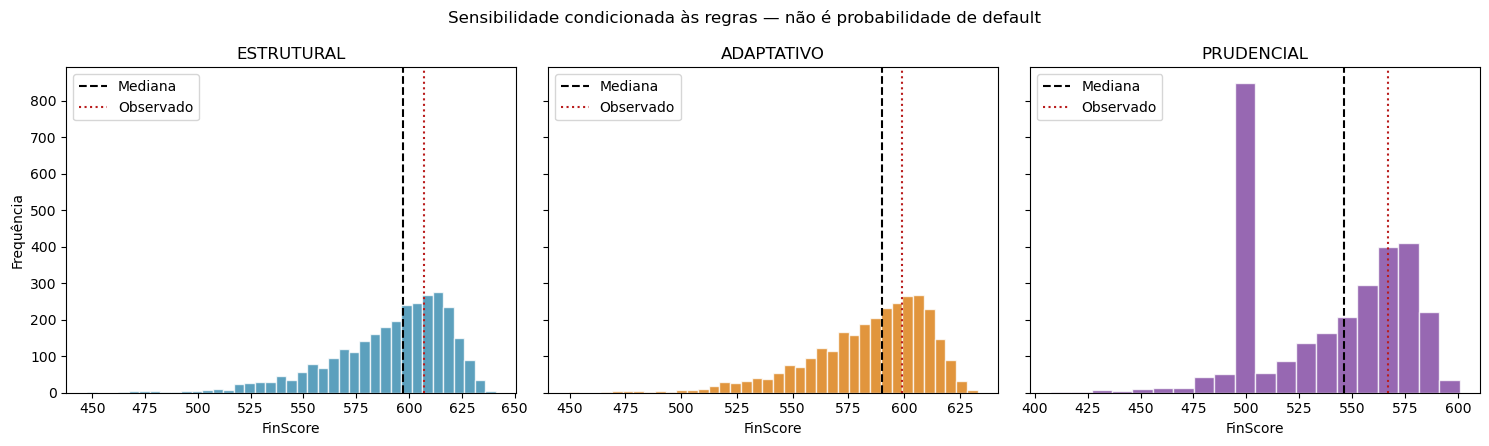

In [27]:
if MODELO_APTO:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    methods = ["estrutural", "adaptativo", "prudencial"]
    colors = ["#2E86AB", "#D97706", "#7A3E9D"]

    for ax, method, color in zip(axes, methods, colors):
        column = f"finscore_{method}"
        ax.hist(
            df_simulacoes[column], bins="fd", color=color,
            alpha=0.78, edgecolor="white"
        )
        ax.axvline(
            df_simulacoes[column].median(), color="black",
            linestyle="--", label="Mediana"
        )
        observed_value = finscore_observado.get(column, np.nan)
        if np.isfinite(observed_value):
            ax.axvline(
                observed_value, color="#B91C1C",
                linestyle=":", label="Observado"
            )
        ax.set_title(method.upper())
        ax.set_xlabel("FinScore")
        ax.legend()

    axes[0].set_ylabel("Frequência")
    fig.suptitle("Sensibilidade condicionada às regras — não é probabilidade de default")
    plt.tight_layout()
    plt.show()

## 6. Evidência externa — Serasa


In [28]:
def assess_external_credit(
    finscore_prudential,
    serasa_score,
    consultation_date=None,
    severe_restriction=False,
) -> pd.DataFrame:
    if serasa_score is None or pd.isna(serasa_score):
        return pd.DataFrame([{
            "serasa_score": np.nan,
            "data_consulta": consultation_date,
            "status": "AUSENTE",
            "divergencia_pontos": np.nan,
            "nivel_divergencia": "não calculado",
            "direcao": "avaliação externa ausente",
            "restricao_grave": bool(severe_restriction),
            "score_integrado": np.nan,
        }])
    if not 0 <= float(serasa_score) <= 1000:
        raise ValueError("SERASA_SCORE deve estar entre 0 e 1.000.")

    if pd.isna(finscore_prudential):
        difference = np.nan
        level = "não calculado"
        direction = "FinScore indisponível"
    else:
        signed = float(serasa_score) - float(finscore_prudential)
        difference = abs(signed)
        if difference <= 100:
            level = "baixa"
        elif difference <= 200:
            level = "moderada"
        elif difference <= 300:
            level = "relevante"
        else:
            level = "elevada"
        direction = (
            "convergente" if difference <= 100
            else "evidência externa mais favorável" if signed > 0
            else "evidência externa mais desfavorável"
        )

    status = "ESCALONAR_RESTRICAO_GRAVE" if severe_restriction else "ANALISAR_CONJUNTAMENTE"
    return pd.DataFrame([{
        "serasa_score": float(serasa_score),
        "data_consulta": consultation_date,
        "status": status,
        "divergencia_pontos": difference,
        "nivel_divergencia": level,
        "direcao": direction,
        "restricao_grave": bool(severe_restriction),
        # Deliberadamente ausente: não há média automática.
        "score_integrado": np.nan,
    }])


df_serasa = assess_external_credit(
    finscore_observado.get("finscore_prudencial", np.nan),
    SERASA_SCORE,
    SERASA_DATA_CONSULTA,
    SERASA_RESTRICAO_GRAVE,
)
display(df_serasa)


,serasa_score,data_consulta,status,divergencia_pontos,nivel_divergencia,direcao,restricao_grave,score_integrado
0,700.0000,2026-07-23,ANALISAR_CONJUNTAMENTE,133.0588,moderada,evidência externa mais favorável,False,NaN


## 7. Autotestes e propriedades do modelo

In [29]:
def synthetic_valid_data() -> pd.DataFrame:
    data = {
        "ano": [2023, 2024, 2025],
        "p_Caixa_Equivalentes": [100, 120, 150],
        "p_Contas_Receber_Clientes": [300, 330, 360],
        "p_Estoques": [200, 210, 220],
        "p_Ativo_Circulante": [700, 760, 830],
        "p_Imobilizado_Liquido": [500, 540, 580],
        "p_Ativo_Total": [1400, 1500, 1600],
        "p_Fornecedores": [150, 160, 170],
        "p_Obrigacoes_Tributarias_CP": [40, 45, 50],
        "p_Obrigacoes_Trabalhistas_CP": [60, 65, 70],
        "p_Passivo_Circulante": [400, 420, 430],
        "p_Passivo_Nao_Circulante": [300, 280, 250],
        "p_Emprestimos_Financiamentos_CP": [100, 90, 80],
        "p_Emprestimos_Financiamentos_LP": [250, 230, 200],
        "p_Patrimonio_Liquido": [700, 800, 920],
        "r_Receita_Liquida": [2000, 2200, 2420],
        "r_CMV_CPV_CSV": [1200, 1300, 1400],
        "r_Resultado_Antes_IR_CSLL": [200, 240, 300],
        "r_Lucro_Liquido": [140, 168, 210],
        "r_Receitas_Financeiras": [10, 10, 12],
        "r_Despesa_de_Impostos": [60, 72, 90],
        "r_Despesas_Financeiras": [50, 45, 40],
    }
    return pd.DataFrame(data)


def run_self_tests() -> pd.DataFrame:
    tests = []

    def check(name, condition, detail=""):
        tests.append({
            "teste": name,
            "status": "PASSOU" if bool(condition) else "FALHOU",
            "detalhe": detail,
        })

    base = synthetic_valid_data()
    original = base.copy(deep=True)
    empty_report = pd.DataFrame(columns=QUALITY_COLUMNS)
    prepared, quality, audit, status = validate_correct_and_prepare(
        base, empty_report, []
    )

    check("21 contas primárias", len(PRIMARY) == 21)
    check("base sintética aprovada", status["apto_calculo"])
    check("base sintética sem correções", audit.empty)
    check("dados reportados imutáveis", base.equals(original))

    derived = derive(prepared)
    balance_difference = (
        prepared.p_Ativo_Total - prepared.p_Passivo_Circulante
        - prepared.p_Passivo_Nao_Circulante
        - prepared.p_Patrimonio_Liquido
    )
    check("identidade do balanço", np.allclose(balance_difference, 0))

    index_table = indices(derived)
    score_table = score_indices(index_table)
    scores, profiles, temporal, contributions = calculate_scores(
        index_table, score_table
    )
    cap, _ = evaluate_prudential_caps(index_table, prepared)
    scores["finscore_prudencial"] = min(
        scores["finscore_prudencial_pre_cap"], cap
    )
    check(
        "scores limitados a 0-1000",
        all(0 <= scores[k] <= 1000 for k in [
            "finscore_estrutural", "finscore_adaptativo",
            "finscore_prudencial",
        ]),
    )
    check(
        "gargalo reduz ou mantém score",
        scores["finscore_estrutural_pos_gargalo"]
        <= scores["finscore_estrutural"] + 1e-10
        and scores["finscore_adaptativo_pos_gargalo"]
        <= scores["finscore_adaptativo"] + 1e-10,
    )
    check(
        "pesos PCA válidos",
        all(
            np.isclose(profile.weights.sum(), 1.0)
            and (profile.weights >= 0).all()
            for profile in profiles.values()
        ),
    )
    check(
        "participação PCA limitada a 15%",
        all(
            profile.diagnostics["participacao_adaptativa"]
            in {0.0, PCA_ADAPTIVE_SHARE}
            for profile in profiles.values()
        ),
    )

    # Invariância à unidade monetária.
    scaled = base.copy()
    scaled[PRIMARY] = scaled[PRIMARY] * 1000
    scaled_scores, _ = score_prepared_base(scaled)
    check(
        "invariância à unidade monetária",
        np.isclose(
            scores["finscore_prudencial"],
            scaled_scores["finscore_prudencial"],
            atol=1e-8,
        ),
    )

    # Monotonicidade de todas as curvas conforme sua direção econômica.
    monotonic = True
    for indicator, points in ANCHORS.items():
        notes = np.array([p[1] for p in points], dtype=float)
        direction = INDICATOR_DIRECTION.get(indicator, 1)
        monotonic &= (
            np.all(np.diff(notes) >= -1e-12)
            if direction > 0
            else np.all(np.diff(notes) <= 1e-12)
        )
    check("curvas monotônicas", monotonic)

    # Dívida maior não pode melhorar o resultado, mantido o restante.
    debt_stress = base.copy()
    increment = 100.0
    debt_stress["p_Emprestimos_Financiamentos_CP"] += increment
    debt_stress["p_Passivo_Circulante"] += increment
    debt_stress["p_Ativo_Total"] += increment
    debt_scores, _ = score_prepared_base(debt_stress, profiles)
    check(
        "aumento de dívida não melhora score",
        debt_scores["finscore_prudencial"]
        <= scores["finscore_prudencial"] + 1e-10,
    )

    # Caixa adicional financiado por PL não deve piorar liquidez/capitalização.
    cash_gain = base.copy()
    cash_gain["p_Caixa_Equivalentes"] += increment
    cash_gain["p_Ativo_Circulante"] += increment
    cash_gain["p_Ativo_Total"] += increment
    cash_gain["p_Patrimonio_Liquido"] += increment
    cash_scores, _ = score_prepared_base(cash_gain, profiles)
    check(
        "aumento de caixa com capital não piora score",
        cash_scores["finscore_prudencial"]
        >= scores["finscore_prudencial"] - 1e-10,
    )

    # Um núcleo crítico não pode ser integralmente compensado.
    check(
        "núcleo crítico não é integralmente compensado",
        _geometric_nucleus_score(950, 200)
        < NUCLEUS_WEIGHTS["EO"] * 950 + NUCLEUS_WEIGHTS["FP"] * 200,
    )

    result_a, diagnostics_a = run_sensitivity(
        prepared, 120, 12345, profiles
    )
    result_b, diagnostics_b = run_sensitivity(
        prepared, 120, 12345, profiles
    )
    score_columns = [
        "finscore_estrutural", "finscore_adaptativo",
        "finscore_prudencial",
    ]
    check(
        "reprodutibilidade por semente",
        np.allclose(result_a[score_columns], result_b[score_columns]),
    )
    check(
        "simulações dentro da escala",
        result_a[score_columns].ge(0).all().all()
        and result_a[score_columns].le(1000).all().all(),
    )
    check(
        "drivers respeitam amplitudes declaradas",
        diagnostics_a["drivers_fora_limite"] == 0,
    )
    check(
        "PL não é residual do balanço",
        diagnostics_a["limites_choques"].loc[
            diagnostics_a["limites_choques"]["conta"].eq(
                "p_Patrimonio_Liquido"
            ),
            "natureza_simulacao",
        ].eq("DRIVER_SORTEADO").all(),
    )
    deterministic = run_deterministic_scenarios(prepared, profiles)
    check(
        "cenários determinísticos contabilmente válidos",
        deterministic["status"].eq("VALIDO").all(),
    )

    corrupted = base.copy()
    corrupted.loc[2, "p_Passivo_Circulante"] = 100
    _, corrupt_quality, corrupt_audit, corrupt_status = (
        validate_correct_and_prepare(corrupted, empty_report, [])
    )
    check(
        "subtotal inconsistente é colocado em quarentena",
        corrupt_quality["tipo"].eq(
            "subtotal_inferior_componentes"
        ).any()
        and corrupt_audit["acao"].eq(
            "QUARENTENA_DETALHAMENTO"
        ).any(),
    )

    serasa_test = assess_external_credit(
        scores["finscore_prudencial"], 500
    )
    check(
        "Serasa não gera média automática",
        pd.isna(serasa_test.loc[0, "score_integrado"]),
    )

    known_problem = base.copy()
    known_problem.loc[0, "p_Passivo_Nao_Circulante"] = 100
    known_problem.loc[0, "p_Ativo_Total"] = (
        known_problem.loc[0, "p_Passivo_Circulante"]
        + known_problem.loc[0, "p_Patrimonio_Liquido"]
    )
    known_problem.loc[0, "p_Ativo_Circulante"] = 600
    known_problem.loc[2, "p_Passivo_Nao_Circulante"] = np.nan
    known_problem.loc[2, "p_Passivo_Circulante"] = 430
    known_problem.loc[2, "p_Obrigacoes_Tributarias_CP"] = 300
    known_problem.loc[2, "p_Obrigacoes_Trabalhistas_CP"] = 250
    corrected, known_quality, known_audit, known_status = (
        validate_correct_and_prepare(known_problem, empty_report, [])
    )
    check(
        "correção automática não altera origem",
        known_problem.loc[0, "p_Passivo_Nao_Circulante"] == 100,
    )
    check(
        "rubrica redundante corrigida apenas na análise",
        np.isclose(
            corrected.loc[0, "p_Passivo_Nao_Circulante"], 0
        ),
    )
    check(
        "parcela ausente inferida e auditada",
        pd.notna(corrected.loc[2, "p_Passivo_Nao_Circulante"])
        and known_audit["acao"].eq("INFERENCIA_IDENTIDADE").any(),
    )
    check(
        "score com correção material é provisório",
        known_status["apto_calculo"]
        and known_status["score_provisorio"]
        and not known_status["apto_decisao"],
    )

    return pd.DataFrame(tests)


df_autotestes = (
    run_self_tests() if EXECUTAR_AUTOTESTES else pd.DataFrame()
)
if EXECUTAR_AUTOTESTES:
    display(df_autotestes)
    if not df_autotestes["status"].eq("PASSOU").all():
        raise AssertionError(
            "Há autoteste(s) com falha; revise antes de usar o modelo."
        )

,teste,status,detalhe
0,21 contas primárias,PASSOU,
1,base sintética aprovada,PASSOU,
2,base sintética sem correções,PASSOU,
3,dados reportados imutáveis,PASSOU,
4,identidade do balanço,PASSOU,
5,scores limitados a 0-1000,PASSOU,
6,gargalo reduz ou mantém score,PASSOU,
7,pesos PCA válidos,PASSOU,
8,participação PCA limitada a 15%,PASSOU,
9,invariância à unidade monetária,PASSOU,


## 8. Exportação auditável

In [30]:
from openpyxl.comments import Comment
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter


PARAMETROS_REGRAS = {
    "versao": VERSAO_MODELO,
    "hash_codigo": HASH_CODIGO_MODELO,
    "politica_correcao": POLITICA_CORRECAO,
    "limiar_confianca_automatica": LIMIAR_CONFIANCA_AUTOMATICA,
    "limiar_materialidade": LIMIAR_MATERIALIDADE,
    "limiar_vies_alto": LIMIAR_VIES_ALTO,
    "tolerancia_balanco": BALANCE_TOLERANCE,
    "cobertura_minima_nucleo": MIN_NUCLEUS_COVERAGE,
    "participacao_pca": PCA_ADAPTIVE_SHARE,
    "repeticoes_estabilidade_pca": PCA_STABILITY_REPETITIONS,
    "limiar_l1_pca": PCA_MAX_MEAN_L1_DISTANCE,
    "limiar_cosseno_pca": PCA_MIN_MEAN_COSINE,
    "pesos_nucleos": NUCLEUS_WEIGHTS,
    "peso_gargalo": BOTTLENECK_SHARE,
    "pesos_temporais": TEMPORAL_COMPONENT_WEIGHTS,
    "caps_prudenciais": PRUDENTIAL_CAPS,
    "ancoras": ANCHORS,
    "pesos_fixos": FIXED_WEIGHTS,
}
HASH_REGRAS = hashlib.sha256(
    json.dumps(PARAMETROS_REGRAS, sort_keys=True).encode("utf-8")
).hexdigest()

configuration_rows = [
    ("versao", VERSAO_MODELO),
    ("hash_codigo_modelo", HASH_CODIGO_MODELO),
    ("planilha", str(CAMINHO_PLANILHA)),
    ("aba", ABA_DADOS),
    ("simulacoes", NUM_SIMULACOES),
    ("semente", SEMENTE),
    (
        "data_hora_processamento",
        DATA_HORA_PROCESSAMENTO.strftime("%Y-%m-%d %H:%M:%S"),
    ),
    ("politica_correcao", POLITICA_CORRECAO),
    ("aplicar_correcoes_automaticas", APLICAR_CORRECOES_AUTOMATICAS),
    ("limiar_confianca_automatica", LIMIAR_CONFIANCA_AUTOMATICA),
    ("limiar_materialidade", LIMIAR_MATERIALIDADE),
    ("limiar_vies_alto", LIMIAR_VIES_ALTO),
    ("delta_min", DELTA_MIN),
    ("delta_max", DELTA_MAX),
    ("peso_EO", NUCLEUS_WEIGHTS["EO"]),
    ("peso_FP", NUCLEUS_WEIGHTS["FP"]),
    ("peso_gargalo", BOTTLENECK_SHARE),
    ("participacao_pca", PCA_ADAPTIVE_SHARE),
    ("pca_variaveis_minimas", PCA_MIN_ACTIVE_VARIABLES),
    ("pca_repeticoes_estabilidade", PCA_STABILITY_REPETITIONS),
    ("pca_l1_maximo", PCA_MAX_MEAN_L1_DISTANCE),
    ("pca_cosseno_minimo", PCA_MIN_MEAN_COSINE),
    ("peso_temporal_nivel", TEMPORAL_COMPONENT_WEIGHTS["nivel_atual"]),
    ("peso_temporal_trajetoria", TEMPORAL_COMPONENT_WEIGHTS["trajetoria"]),
    ("peso_temporal_resiliencia", TEMPORAL_COMPONENT_WEIGHTS["resiliencia"]),
    ("cobertura_minima_nucleo", MIN_NUCLEUS_COVERAGE),
    ("proxy_juros", USAR_DESPESAS_FINANCEIRAS_COMO_PROXY_JUROS),
    ("status_base", status_qualidade["status"]),
    ("classificacao_uso", status_qualidade["classificacao_uso"]),
    ("indice_confiabilidade", q_observado),
    ("hash_dados_reportados", HASH_DADOS_REPORTADOS),
    ("hash_dados_utilizados", HASH_DADOS_UTILIZADOS),
    ("hash_regras", HASH_REGRAS),
]
df_configuracao = pd.DataFrame(
    configuration_rows, columns=["parametro", "valor"]
)

df_resumo_modelo = pd.DataFrame({
    "campo": [
        "Versão",
        "Status do cálculo",
        "Classificação de uso",
        "Apto para decisão",
        "Natureza do score",
        "Índice de confiabilidade",
        "Classificação da confiabilidade",
        "Correções/quarentenas aplicadas",
        "Pendências de confirmação",
        "Alertas de viés alto/crítico",
        "Score EO estrutural",
        "Score FP estrutural",
        "FinScore estrutural geométrico",
        "FinScore adaptativo geométrico",
        "FinScore prudencial antes do cap",
        "Cap prudencial aplicável",
        "FinScore prudencial final",
        "Faixa de incerteza inferior",
        "Faixa de incerteza superior",
        "Hash da base reportada",
        "Hash da base utilizada",
        "Hash das regras",
        "Hash do código",
    ],
    "valor": [
        VERSAO_MODELO,
        status_qualidade["status"],
        status_qualidade["classificacao_uso"],
        "SIM" if status_qualidade["apto_decisao"] else "NÃO",
        finscore_observado.get("natureza_resultado", "NÃO CALCULADO"),
        q_observado,
        confiabilidade_observada["classificacao_confiabilidade"],
        status_qualidade["correcoes_aplicadas"],
        status_qualidade["correcoes_pendentes_confirmacao"],
        status_qualidade.get("alertas_vies_alto_critico", 0),
        finscore_observado.get("nucleo_EO_estrutural", np.nan),
        finscore_observado.get("nucleo_FP_estrutural", np.nan),
        finscore_observado.get("finscore_estrutural", np.nan),
        finscore_observado.get("finscore_adaptativo", np.nan),
        finscore_observado.get("finscore_prudencial_pre_cap", np.nan),
        finscore_observado.get("cap_prudencial_aplicavel", np.nan),
        finscore_observado.get("finscore_prudencial", np.nan),
        finscore_observado.get("faixa_incerteza_inferior", np.nan),
        finscore_observado.get("faixa_incerteza_superior", np.nan),
        HASH_DADOS_REPORTADOS,
        HASH_DADOS_UTILIZADOS,
        HASH_REGRAS,
        HASH_CODIGO_MODELO,
    ],
})


def _style_workbook(workbook):
    '''Formatação operacional sem esconder a trilha de auditoria.'''
    navy = "17365D"
    red = "F4CCCC"
    amber = "FCE5CD"
    green = "D9EAD3"
    blue = "D9EAF7"

    for worksheet in workbook.worksheets:
        worksheet.freeze_panes = "A2"
        worksheet.sheet_view.showGridLines = False
        worksheet.auto_filter.ref = worksheet.dimensions
        for cell in worksheet[1]:
            cell.fill = PatternFill("solid", fgColor=navy)
            cell.font = Font(color="FFFFFF", bold=True)
            cell.alignment = Alignment(
                horizontal="center", vertical="center", wrap_text=True
            )
        worksheet.row_dimensions[1].height = 34

        for column_cells in worksheet.columns:
            letter = get_column_letter(column_cells[0].column)
            max_length = 0
            for cell in column_cells[:200]:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))
                cell.alignment = Alignment(vertical="top", wrap_text=True)
            worksheet.column_dimensions[letter].width = min(
                max(max_length + 2, 11), 55
            )

        headers = {
            cell.value: cell.column
            for cell in worksheet[1]
            if cell.value is not None
        }
        for label in [
            "severidade", "potencial_vies", "risco_vies", "status",
            "status_acao", "classificacao_uso",
        ]:
            if label not in headers:
                continue
            column = headers[label]
            for row in range(2, worksheet.max_row + 1):
                cell = worksheet.cell(row, column)
                text = str(cell.value).upper()
                if "CRIT" in text or "BLOQUE" in text or "NAO APTA" in text:
                    cell.fill = PatternFill("solid", fgColor=red)
                elif "ALTO" in text or "PROVIS" in text or "PEND" in text:
                    cell.fill = PatternFill("solid", fgColor=amber)
                elif "PASS" in text or "DECISORIO" in text or "CONTROLADO" in text:
                    cell.fill = PatternFill("solid", fgColor=green)
                elif "QUARENTENA" in text or "INFO" in text:
                    cell.fill = PatternFill("solid", fgColor=blue)

        for header, column in headers.items():
            header_text = str(header).lower()
            if any(token in header_text for token in [
                "valor_", "delta_absoluto", "score", "observado",
                "media", "mediana", "minimo", "maximo", "cap",
            ]):
                for row in range(2, worksheet.max_row + 1):
                    worksheet.cell(row, column).number_format = (
                        '#,##0.00;[Red](#,##0.00);-'
                    )
            if any(token in header_text for token in [
                "percentual", "materialidade", "confianca",
                "correlacao", "variancia", "participacao", "peso",
                "freq_", "impacto_absoluto", "cobertura",
                "amplitude", "choque",
            ]):
                for row in range(2, worksheet.max_row + 1):
                    worksheet.cell(row, column).number_format = "0.00%"

        if worksheet.title == "indices_observados":
            percentage_indicators = {
                "crescimento_receita", "margem_bruta", "margem_ebit",
                "margem_liquida", "capitalizacao",
                "endividamento_exigivel", "ccl_ativo",
                "divida_liquida_ativo", "composicao_endividamento",
            }
            multiple_indicators = {
                "giro_ativo", "liquidez_corrente", "liquidez_seca",
                "cobertura_juros",
            }
            for header, column in headers.items():
                if header in percentage_indicators:
                    for row in range(2, worksheet.max_row + 1):
                        worksheet.cell(row, column).number_format = "0.00%"
                elif header in multiple_indicators:
                    for row in range(2, worksheet.max_row + 1):
                        worksheet.cell(row, column).number_format = "0.00x"

        narrative_heights = {
            "correcoes_auditoria": 72,
            "alertas_vies_material": 72,
            "qualidade_dados": 48,
            "motivos_nan": 48,
            "caps_prudenciais": 48,
            "intervalos_incerteza": 48,
        }
        if worksheet.title in narrative_heights:
            for row in range(2, worksheet.max_row + 1):
                worksheet.row_dimensions[row].height = (
                    narrative_heights[worksheet.title]
                )

    if "correcoes_auditoria" in workbook.sheetnames:
        ws = workbook["correcoes_auditoria"]
        comments = {
            "valor_original": "Valor lido da planilha-fonte, nunca sobrescrito.",
            "valor_utilizado": "Valor empregado somente na cópia analítica.",
            "confianca": (
                "Confiança da regra; não equivale a probabilidade estatística."
            ),
            "materialidade_pct_ativo": (
                "Magnitude da mudança dividida pelo Ativo Total do exercício."
            ),
            "confirmado": (
                "Verdadeiro somente após verificação documental."
            ),
        }
        for cell in ws[1]:
            if cell.value in comments:
                cell.comment = Comment(comments[cell.value], "FinScore")

    if "resumo_modelo" in workbook.sheetnames:
        ws = workbook["resumo_modelo"]
        for row in range(2, ws.max_row + 1):
            field = str(ws.cell(row, 1).value)
            if any(token in field for token in [
                "Status", "Natureza", "Apto", "Classificação de uso",
            ]):
                ws.cell(row, 2).font = Font(bold=True)
                text = str(ws.cell(row, 2).value).upper()
                fill = (
                    red if "NÃO" in text or "NAO" in text or "BLOQUE" in text
                    else amber if "PROVIS" in text or "EXPLOR" in text
                    else green
                )
                ws.cell(row, 2).fill = PatternFill("solid", fgColor=fill)


def export_audit_workbook(path: Path):
    sheets = {
        "resumo_modelo": df_resumo_modelo,
        "confiabilidade": df_confiabilidade_componentes,
        "correcoes_auditoria": df_correcoes_auditoria,
        "alertas_vies_material": df_alertas_vies,
        "qualidade_dados": df_qualidade,
        "rastreabilidade_contas": df_rastreabilidade_contas,
        "contas_reportadas": df_contas_reportadas,
        "contas_utilizadas": df_contas_analise,
        "evidencia_serasa": df_serasa,
        "autotestes": df_autotestes,
        "configuracao": df_configuracao,
    }
    if MODELO_APTO:
        sheets.update({
            "score_observado": pd.DataFrame([finscore_observado]),
            "score_temporal": df_score_temporal,
            "contribuicoes_score": df_contribuicoes_score,
            "caps_prudenciais": df_caps_prudenciais,
            "intervalos_incerteza": df_intervalos_incerteza,
            "contas_derivadas": df_contas_derivadas,
            "indices_observados": df_indices_observados,
            "notas_observadas": df_notas_observadas,
            "motivos_nan": df_motivos_nan,
            "diagnostico_pca": df_diagnostico_pca,
            "pesos_pca": df_pesos_pca,
            "cargas_pca": df_cargas_pca,
            "cenarios_deterministicos": df_cenarios_deterministicos,
            "resumo_simulacao": df_resumo,
            "simulacoes": df_simulacoes,
            "sensibilidade": df_sensibilidade,
            "amplitudes": df_amplitudes,
        })

    with pd.ExcelWriter(path, engine="openpyxl") as writer:
        for sheet_name, table in sheets.items():
            table.to_excel(
                writer, sheet_name=sheet_name[:31], index=False
            )
        _style_workbook(writer.book)


if EXPORTAR_EXCEL:
    export_audit_workbook(ARQUIVO_SAIDA)
    print(f"Resultados salvos em: {ARQUIVO_SAIDA.resolve()}")
else:
    print("Exportação Excel desativada.")

Resultados salvos em: C:\Users\ferna\Documents\dev\Finscore\FinScore\V. 2 (Pudim)\algoritmos\resultados_finscore_2.0.7_20260723_1533.xlsx


## 9. Interpretação e limites

Leia a saída nesta ordem:

1. **classificação de uso e confiabilidade** — determinam se o resultado pode apoiar decisão;
2. **Score EO e FP** — mostram qual dimensão limita a capacidade econômica;
3. **FinScore geométrico, gargalo e cap** — explicam a passagem ao resultado prudencial;
4. **faixa de incerteza** — mostra o efeito parcial de dívida onerosa não classificada;
5. **nível, trajetória e resiliência** — mostram por que cada indicador contribuiu;
6. **PCA** — informa o que mais variou, desde que o teste de estabilidade permita ajuste;
7. **cenários determinísticos e Monte Carlo** — avaliam sensibilidade às regras adotadas.

### Limites que permanecem

- três exercícios não permitem inferência estatística robusta nem estimação de PD;
- pesos, curvas e caps ainda são normativos e precisam de validação transversal;
- a faixa de incerteza cobre a classificação desconhecida da dívida, não todas as omissões;
- Monte Carlo representa sensibilidade condicionada, não previsão econômica;
- Serasa continua sendo evidência comportamental separada;
- julgamento de crédito, documentos assinados, notas explicativas e contexto setorial continuam indispensáveis.